<a href="https://colab.research.google.com/github/gerritgr/clam/blob/main/Clam_exp1_exp2_redone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clam: Full Code

## Exp 1

### Main Code

In [ ]:
# ============================================================
# Cell 1: Run experiments and save CSV outputs
# ============================================================

import os
import math
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt


# ============================================================
# Hyperparameters and parameters
# ============================================================

SEED = 42                 # Global random seed for reproducibility
ROW = 100                 # Number of regions
COL = 16                   # Number of subregions per region
EXP_DIR = "exp1"          # Output folder for Experiment 1

N_SWAPS = 100             # Number of random pair swaps in context matrix C
NOISE_STD = 0.1          # Gaussian noise added to Y

N_EPOCHS = 4000           # Number of training epochs
LR = 1e-3                 # Learning rate
WEIGHT_DECAY = 1e-3       # AdamW weight decay for regularization
HIDDEN_DIM = 32           # Hidden layer width
DROPOUT = 0.05            # Dropout probability
PRINT_INTERVAL = 10       # Print loss every n epochs

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# ============================================================
# Reproducibility
# ============================================================

def set_all_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass


set_all_seeds(SEED)


# ============================================================
# Validation
# ============================================================

def is_perfect_square(x):
    r = int(math.sqrt(x))
    return r * r == x


if not is_perfect_square(ROW):
    raise ValueError(f"ROW={ROW} must be a perfect square.")

if not is_perfect_square(COL):
    raise ValueError(f"COL={COL} must be a perfect square.")


os.makedirs(EXP_DIR, exist_ok=True)


# ============================================================
# Ground-truth function f(t, c)
# ============================================================

def true_f_numpy(t, c):
    """
    Ground-truth function.

    If t == 0:
        f = 1

    If t == 1:
        f is given by piecewise linear interpolation over c
        using anchor points:
            (-100, 2), (-2, 2), (0, 1), (1, 0), (100, 0)
    """
    t = np.asarray(t)
    c = np.asarray(c)

    anchor_x = np.array([-100, -2, 0, 1, 100], dtype=float)
    anchor_y = np.array([2, 2, 1, 0, 0], dtype=float)

    y_t1 = np.interp(c, anchor_x, anchor_y)
    y = np.where(t == 0, 1.0, y_t1)

    return y.astype(float)


# ============================================================
# Data generation
# ============================================================

def create_treatment_matrix(row, col):
    """
    Create treatment matrix T.

    Exactly half of the rows are all ones and half are all zeros.
    """
    if row % 2 != 0:
        raise ValueError("ROW must be even to assign exactly half treated rows.")

    row_flags = np.array([1] * (row // 2) + [0] * (row // 2))
    np.random.shuffle(row_flags)

    T = np.repeat(row_flags[:, None], col, axis=1)

    return T.astype(float)


def create_context_matrix(row, col, n_swaps):
    """
    Create context matrix C.

    1. Draw all entries from a normal distribution.
    2. Subtract the row mean so each row sums to zero.
    3. Randomly swap n_swaps pairs of entries.
    """
    C = np.random.normal(loc=0.0, scale=1.0, size=(row, col))
    C = C - C.mean(axis=1, keepdims=True)

    for _ in range(n_swaps):
        r1 = np.random.randint(0, row)
        c1 = np.random.randint(0, col)

        r2 = np.random.randint(0, row)
        c2 = np.random.randint(0, col)

        C[r1, c1], C[r2, c2] = C[r2, c2], C[r1, c1]

    return C.astype(float)


T = create_treatment_matrix(ROW, COL)
C = create_context_matrix(ROW, COL, N_SWAPS)

Y_clean = true_f_numpy(T, C)
Y = Y_clean + np.random.normal(loc=0.0, scale=NOISE_STD, size=(ROW, COL))

T_agg = T.mean(axis=1)
C_agg = C.mean(axis=1)
Y_agg = Y.mean(axis=1)

Y_disagg = np.repeat(Y_agg[:, None], COL, axis=1)

E_true = true_f_numpy(T, C) - true_f_numpy(np.zeros_like(T), C)


# ============================================================
# Save generated data
# ============================================================

pd.DataFrame(T).to_csv(os.path.join(EXP_DIR, "T.csv"), index=False, header=False)
pd.DataFrame(C).to_csv(os.path.join(EXP_DIR, "C.csv"), index=False, header=False)
pd.DataFrame(Y).to_csv(os.path.join(EXP_DIR, "Y.csv"), index=False, header=False)
pd.DataFrame(Y_clean).to_csv(os.path.join(EXP_DIR, "Y_clean.csv"), index=False, header=False)

pd.DataFrame(T_agg).to_csv(os.path.join(EXP_DIR, "T_agg.csv"), index=False, header=False)
pd.DataFrame(C_agg).to_csv(os.path.join(EXP_DIR, "C_agg.csv"), index=False, header=False)
pd.DataFrame(Y_agg).to_csv(os.path.join(EXP_DIR, "Y_agg.csv"), index=False, header=False)

pd.DataFrame(Y_disagg).to_csv(os.path.join(EXP_DIR, "Y_disagg.csv"), index=False, header=False)
pd.DataFrame(E_true).to_csv(os.path.join(EXP_DIR, "LOCATE_true.csv"), index=False, header=False)


# ============================================================
# Model
# ============================================================

class SmallMLP(nn.Module):
    """
    Simple neural network approximating f(t, c).
    """
    def __init__(self, hidden_dim=64, dropout=0.05):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def make_features(T, C):
    """
    Convert T and C matrices into feature tensor with shape ROW x COL x 2.
    """
    X = np.stack([T, C], axis=-1)
    return X.astype(np.float32)


def predict_matrix(model, T_np, C_np):
    """
    Predict element-wise outcome matrix using model f_rec(t, c).
    """
    model.eval()

    X_np = make_features(T_np, C_np)
    X_t = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)

    with torch.no_grad():
        pred = model(X_t.reshape(-1, 2)).reshape(T_np.shape)

    return pred.detach().cpu().numpy()


def compute_locate_matrix(model, T_np, C_np):
    """
    Compute LOCATE:
        E_ij = f_rec(t_ij, c_ij) - f_rec(0, c_ij)
    """
    Y_treated_or_observed = predict_matrix(model, T_np, C_np)
    Y_control = predict_matrix(model, np.zeros_like(T_np), C_np)

    return Y_treated_or_observed - Y_control


def compute_locate_mae_torch(model, T_t, C_t, E_true_t):
    """
    Compute current LOCATE MAE during training.
    """
    X_obs = torch.stack([T_t, C_t], dim=-1)
    X_zero = torch.stack([torch.zeros_like(T_t), C_t], dim=-1)

    pred_obs = model(X_obs.reshape(-1, 2)).reshape(T_t.shape)
    pred_zero = model(X_zero.reshape(-1, 2)).reshape(T_t.shape)

    E_pred = pred_obs - pred_zero
    locate_mae = torch.mean(torch.abs(E_pred - E_true_t))

    return locate_mae


# ============================================================
# Experiment 1a: aggregated loss signal
# ============================================================

def train_exp1a(T, C, Y, Y_agg, E_true):
    """
    Train f_rec using only row-aggregated outcome loss.
    """
    set_all_seeds(SEED)

    model = SmallMLP(hidden_dim=HIDDEN_DIM, dropout=DROPOUT).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    X_np = make_features(T, C)

    X_t = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)
    T_t = torch.tensor(T, dtype=torch.float32, device=DEVICE)
    C_t = torch.tensor(C, dtype=torch.float32, device=DEVICE)
    Y_t = torch.tensor(Y, dtype=torch.float32, device=DEVICE)
    Y_agg_t = torch.tensor(Y_agg, dtype=torch.float32, device=DEVICE)
    E_true_t = torch.tensor(E_true, dtype=torch.float32, device=DEVICE)

    history = []

    for epoch in range(1, N_EPOCHS + 1):
        model.train()

        pred = model(X_t.reshape(-1, 2)).reshape(ROW, COL)
        pred_agg = pred.mean(dim=1)

        loss = torch.mean((pred_agg - Y_agg_t) ** 2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            prediction_error = torch.mean((pred - Y_t) ** 2)
            locate_mae = compute_locate_mae_torch(model, T_t, C_t, E_true_t)

        history.append({
            "epoch": epoch,
            "training_loss": loss.item(),
            "prediction_error": prediction_error.item(),
            "locate_mae": locate_mae.item(),
        })

        if epoch % PRINT_INTERVAL == 0 or epoch == 1:
            print(
                f"[Exp 1a] Epoch {epoch:04d} | "
                f"loss={loss.item():.6f} | "
                f"prediction_error={prediction_error.item():.6f} | "
                f"locate_mae={locate_mae.item():.6f}"
            )

    return model, pd.DataFrame(history)


model_1a, hist_1a = train_exp1a(T, C, Y, Y_agg, E_true)

Y_rec_1a = predict_matrix(model_1a, T, C)
E_1a = compute_locate_matrix(model_1a, T, C)

hist_1a.to_csv(os.path.join(EXP_DIR, "history_1a.csv"), index=False)
pd.DataFrame(Y_rec_1a).to_csv(os.path.join(EXP_DIR, "Y_rec_1a.csv"), index=False, header=False)
pd.DataFrame(E_1a).to_csv(os.path.join(EXP_DIR, "LOCATE_1a.csv"), index=False, header=False)


# ============================================================
# Experiment 1b: uniform disaggregation baseline
# ============================================================

def train_exp1b(T, C, Y, Y_disagg, E_true):
    """
    Train f_rec2 on uniformly disaggregated outcomes.

    Here the loss is available for every element, but the target is naive.
    """
    set_all_seeds(SEED)

    model = SmallMLP(hidden_dim=HIDDEN_DIM, dropout=DROPOUT).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    X_np = make_features(T, C)

    X_t = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)
    T_t = torch.tensor(T, dtype=torch.float32, device=DEVICE)
    C_t = torch.tensor(C, dtype=torch.float32, device=DEVICE)
    Y_t = torch.tensor(Y, dtype=torch.float32, device=DEVICE)
    Y_disagg_t = torch.tensor(Y_disagg, dtype=torch.float32, device=DEVICE)
    E_true_t = torch.tensor(E_true, dtype=torch.float32, device=DEVICE)

    history = []

    for epoch in range(1, N_EPOCHS + 1):
        model.train()

        pred = model(X_t.reshape(-1, 2)).reshape(ROW, COL)

        loss = torch.mean((pred - Y_disagg_t) ** 2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            prediction_error = torch.mean((pred - Y_t) ** 2)
            locate_mae = compute_locate_mae_torch(model, T_t, C_t, E_true_t)

        history.append({
            "epoch": epoch,
            "training_loss": loss.item(),
            "prediction_error": prediction_error.item(),
            "locate_mae": locate_mae.item(),
        })

        if epoch % PRINT_INTERVAL == 0 or epoch == 1:
            print(
                f"[Exp 1b] Epoch {epoch:04d} | "
                f"loss={loss.item():.6f} | "
                f"prediction_error={prediction_error.item():.6f} | "
                f"locate_mae={locate_mae.item():.6f}"
            )

    return model, pd.DataFrame(history)


model_1b, hist_1b = train_exp1b(T, C, Y, Y_disagg, E_true)

Y_rec_1b = predict_matrix(model_1b, T, C)
E_1b = compute_locate_matrix(model_1b, T, C)

hist_1b.to_csv(os.path.join(EXP_DIR, "history_1b.csv"), index=False)
pd.DataFrame(Y_rec_1b).to_csv(os.path.join(EXP_DIR, "Y_rec_1b.csv"), index=False, header=False)
pd.DataFrame(E_1b).to_csv(os.path.join(EXP_DIR, "LOCATE_1b.csv"), index=False, header=False)


# ============================================================
# Save experiment metadata
# ============================================================

metadata = pd.DataFrame({
    "parameter": [
        "SEED",
        "ROW",
        "COL",
        "N_SWAPS",
        "NOISE_STD",
        "N_EPOCHS",
        "LR",
        "WEIGHT_DECAY",
        "HIDDEN_DIM",
        "DROPOUT",
        "PRINT_INTERVAL",
    ],
    "value": [
        SEED,
        ROW,
        COL,
        N_SWAPS,
        NOISE_STD,
        N_EPOCHS,
        LR,
        WEIGHT_DECAY,
        HIDDEN_DIM,
        DROPOUT,
        PRINT_INTERVAL,
    ],
})

metadata.to_csv(os.path.join(EXP_DIR, "metadata.csv"), index=False)

print("\nDone. CSV outputs written to:", EXP_DIR)

[Exp 1a] Epoch 0001 | loss=0.910336 | prediction_error=1.119039 | locate_mae=0.277868
[Exp 1a] Epoch 0010 | loss=0.613064 | prediction_error=0.827778 | locate_mae=0.279406
[Exp 1a] Epoch 0020 | loss=0.346482 | prediction_error=0.568275 | locate_mae=0.289630
[Exp 1a] Epoch 0030 | loss=0.146115 | prediction_error=0.380957 | locate_mae=0.301796
[Exp 1a] Epoch 0040 | loss=0.054735 | prediction_error=0.321376 | locate_mae=0.322156
[Exp 1a] Epoch 0050 | loss=0.046636 | prediction_error=0.331999 | locate_mae=0.321667
[Exp 1a] Epoch 0060 | loss=0.031276 | prediction_error=0.303912 | locate_mae=0.301936
[Exp 1a] Epoch 0070 | loss=0.020772 | prediction_error=0.299767 | locate_mae=0.279151
[Exp 1a] Epoch 0080 | loss=0.014992 | prediction_error=0.300338 | locate_mae=0.276277
[Exp 1a] Epoch 0090 | loss=0.011747 | prediction_error=0.292769 | locate_mae=0.280894
[Exp 1a] Epoch 0100 | loss=0.010148 | prediction_error=0.282591 | locate_mae=0.279299
[Exp 1a] Epoch 0110 | loss=0.009767 | prediction_error

### Visualization

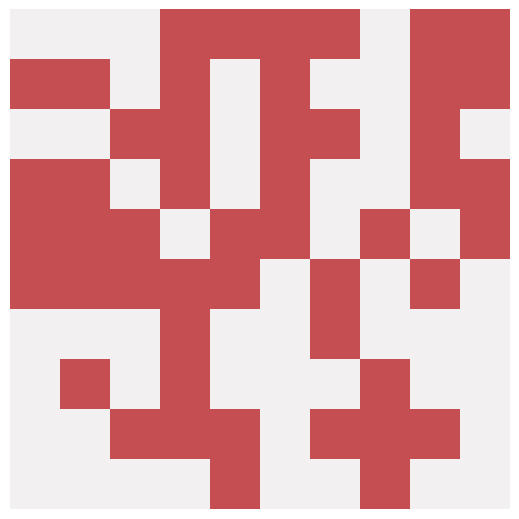

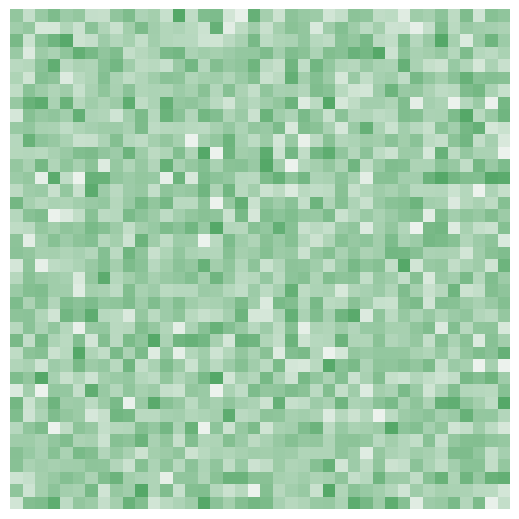

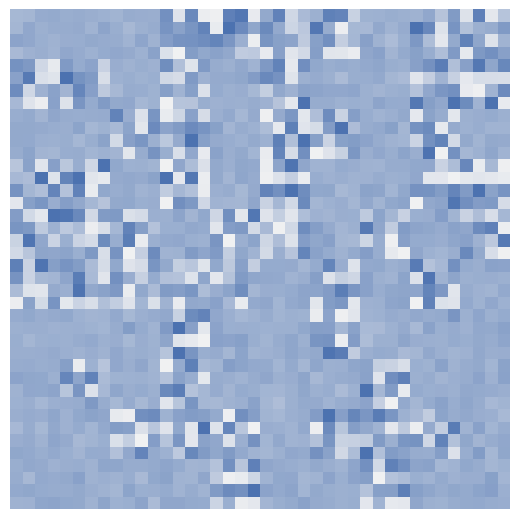

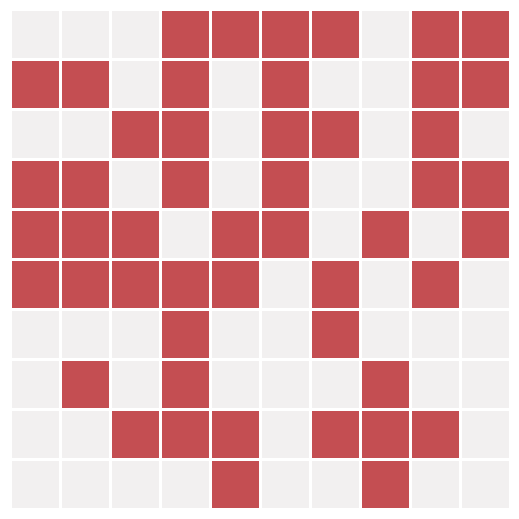

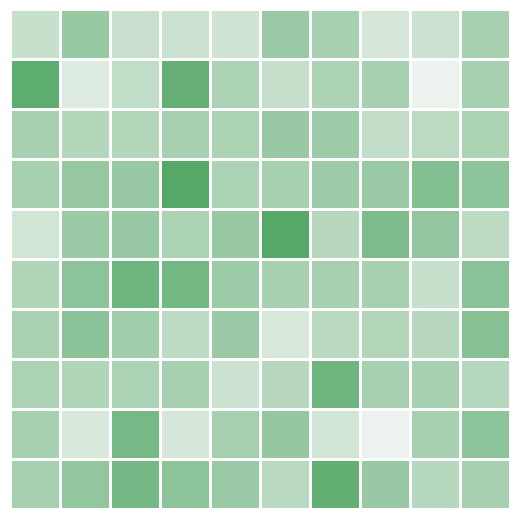

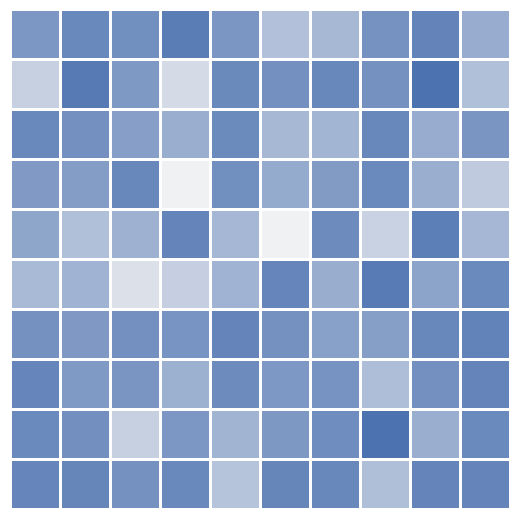

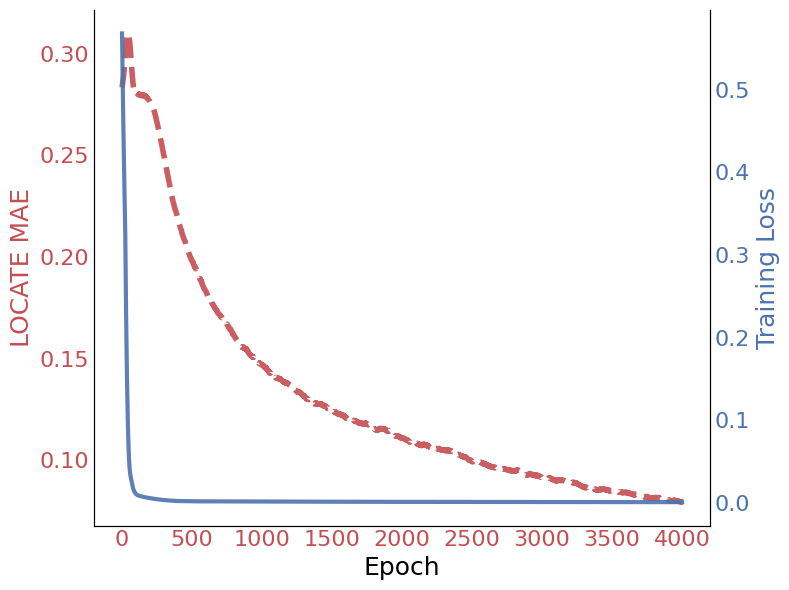

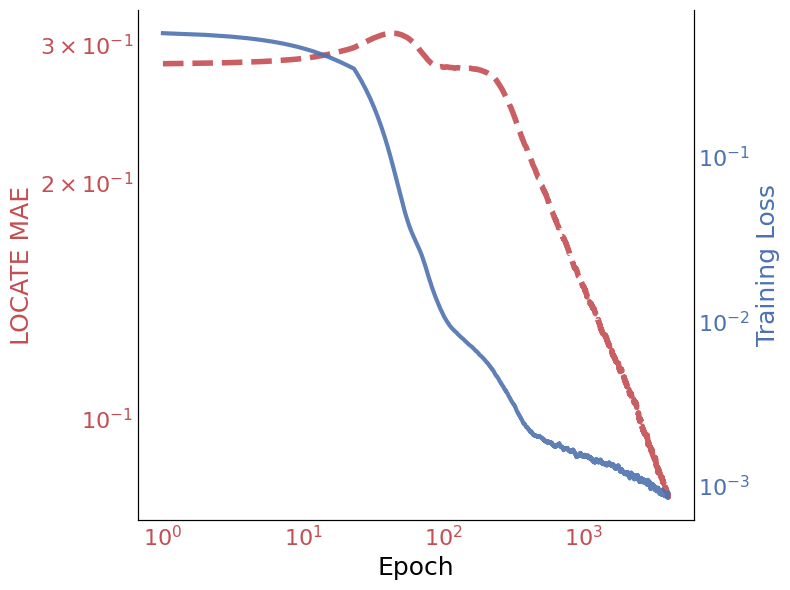

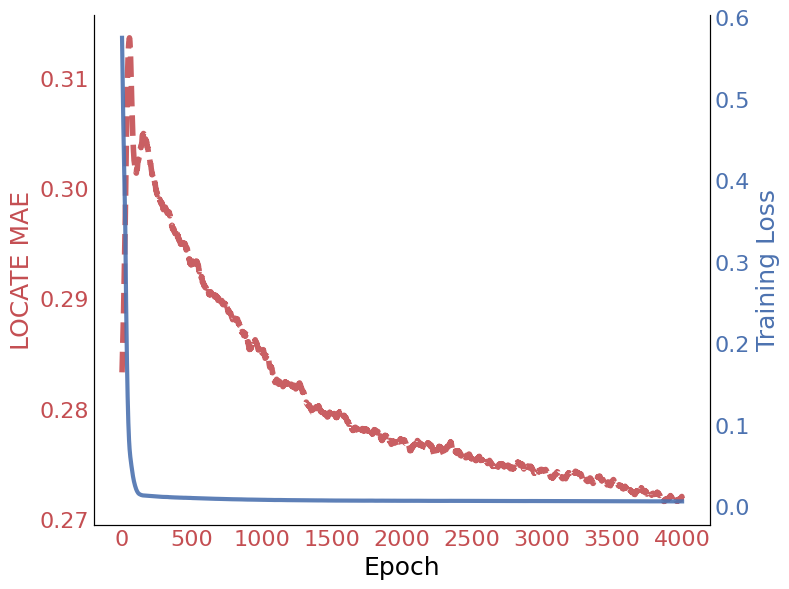

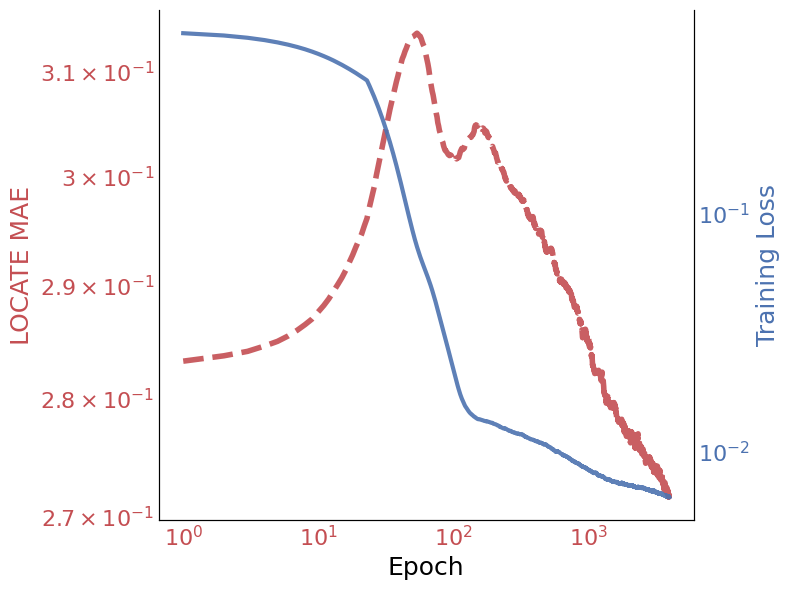

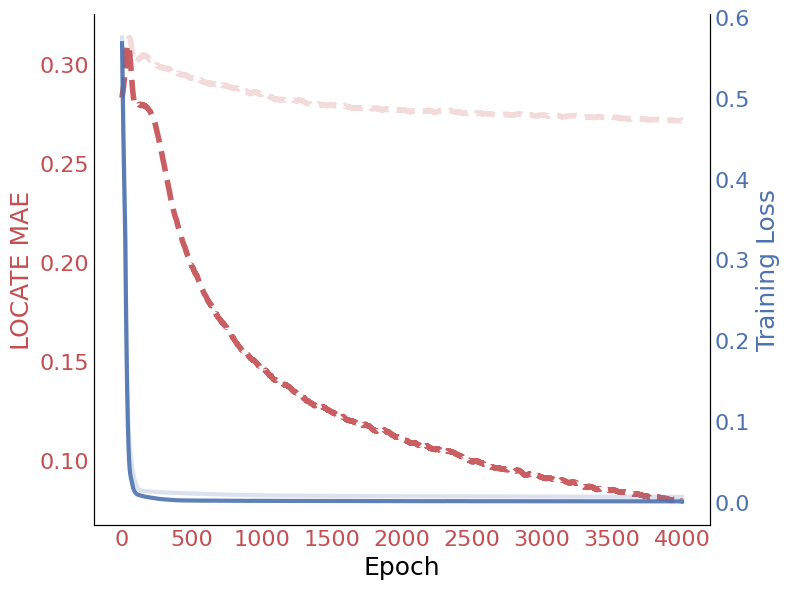

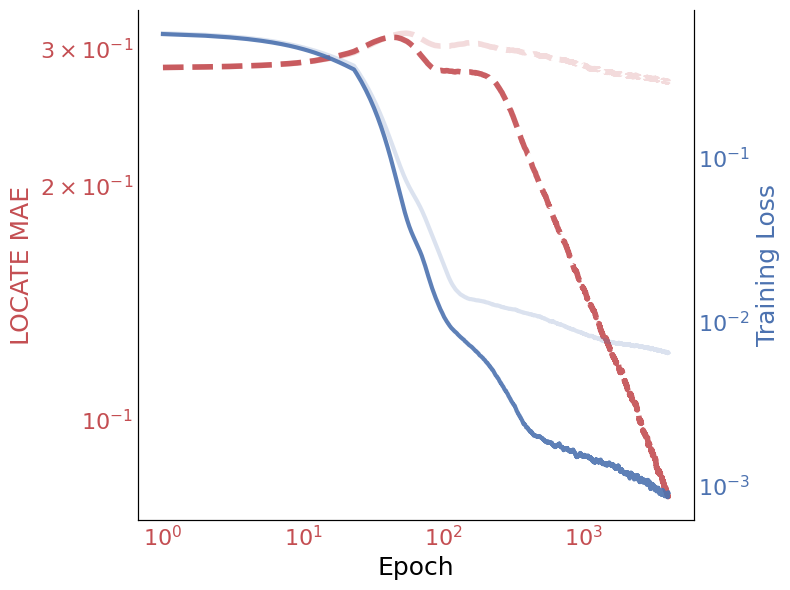

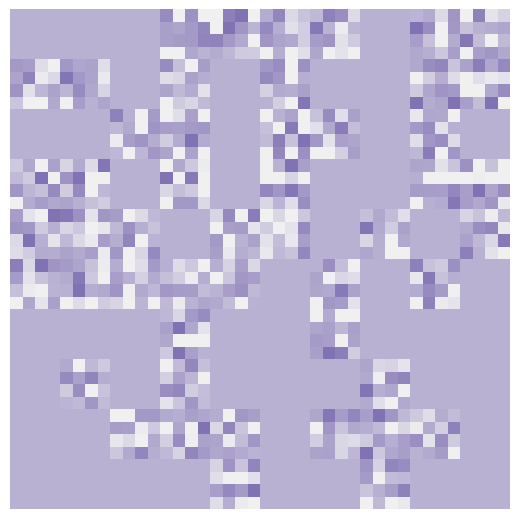

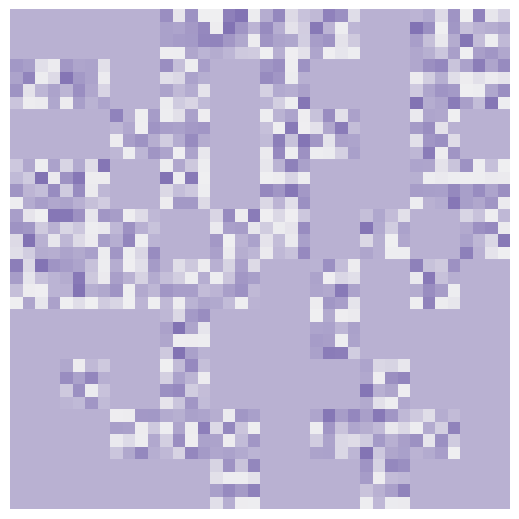

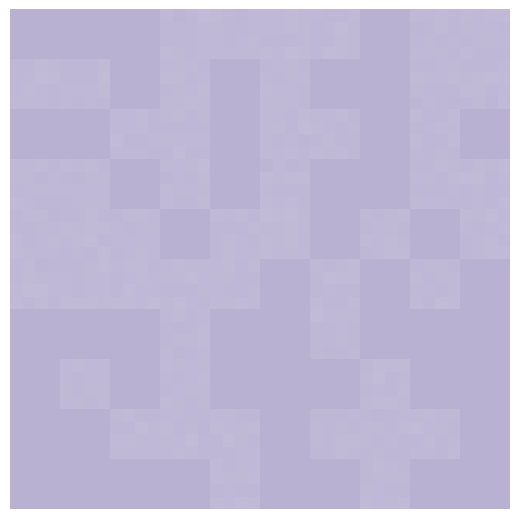


Done. Plots saved to: exp1


In [ ]:
# ============================================================
# Cell 2: Read CSV outputs and create JPG/PDF plots
# ============================================================

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch


# ============================================================
# Parameters
# ============================================================

EXP_DIR = "exp1"
ROW = 100
COL = 16

SMOOTHING_WINDOW = 45  # Moving-average window for smoothing loss curves. Use 1 for no smoothing.

row_side = int(math.sqrt(ROW))
col_side = int(math.sqrt(COL))
grid_side = row_side * col_side

if row_side * row_side != ROW:
    raise ValueError(f"ROW={ROW} must be a perfect square.")

if col_side * col_side != COL:
    raise ValueError(f"COL={COL} must be a perfect square.")


# ============================================================
# Colors and style
# ============================================================

colors = sns.color_palette("deep")

red_cmap    = sns.light_palette(colors[3], as_cmap=True)  # Red, Treatment
blue_cmap   = sns.light_palette(colors[0], as_cmap=True)  # Blue, Outcome
green_cmap  = sns.light_palette(colors[2], as_cmap=True)  # Green, Context
pink_cmap   = sns.light_palette(colors[4], as_cmap=True)  # Pink, Backup / LOCATE
purple_cmap = sns.light_palette(colors[4], as_cmap=True)  # Purple, Backup
orange_cmap = sns.light_palette(colors[1], as_cmap=True)  # Orange, Backup

blue_color = colors[0]
red_color = colors[3]


# ============================================================
# Load CSV files
# ============================================================

def read_matrix(name):
    return pd.read_csv(os.path.join(EXP_DIR, name), header=None).values


def read_vector(name):
    return pd.read_csv(os.path.join(EXP_DIR, name), header=None).values.squeeze()


T = read_matrix("T.csv")
C = read_matrix("C.csv")
Y = read_matrix("Y.csv")

T_agg = read_vector("T_agg.csv")
C_agg = read_vector("C_agg.csv")
Y_agg = read_vector("Y_agg.csv")

E_true = read_matrix("LOCATE_true.csv")
E_1a = read_matrix("LOCATE_1a.csv")
E_1b = read_matrix("LOCATE_1b.csv")

hist_1a = pd.read_csv(os.path.join(EXP_DIR, "history_1a.csv"))
hist_1b = pd.read_csv(os.path.join(EXP_DIR, "history_1b.csv"))


# ============================================================
# Grid conversion functions
# ============================================================

def matrix_to_grid(M):
    """
    Convert ROW x COL matrix into spatial grid.

    ROW regions form sqrt(ROW) x sqrt(ROW).
    COL subregions form sqrt(COL) x sqrt(COL) inside each region.
    """
    M = np.asarray(M)

    if M.shape != (ROW, COL):
        raise ValueError(f"Expected matrix shape {(ROW, COL)}, got {M.shape}.")

    grid = np.zeros((grid_side, grid_side), dtype=float)

    for r in range(ROW):
        region_row = r // row_side
        region_col = r % row_side

        start_i = region_row * col_side
        start_j = region_col * col_side

        block = M[r].reshape(col_side, col_side)

        grid[
            start_i:start_i + col_side,
            start_j:start_j + col_side,
        ] = block

    return grid


def vector_to_regional_grid(v):
    """
    Convert length-ROW vector into sqrt(ROW) x sqrt(ROW) grid.
    """
    v = np.asarray(v)

    if v.shape[0] != ROW:
        raise ValueError(f"Expected vector of length {ROW}, got {v.shape[0]}.")

    return v.reshape(row_side, row_side)


# ============================================================
# Plotting helpers
# ============================================================

def save_heatmap(
    data,
    cmap,
    filename,
    figsize=(5, 5),
    vmin=None,
    vmax=None,
    linewidths=0,
    cbar=False,
):
    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        data,
        ax=ax,
        cmap=cmap,
        square=True,
        linewidths=linewidths,
        cbar=cbar,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

    plt.tight_layout(pad=0)

    fig.savefig(os.path.join(EXP_DIR, f"{filename}.jpg"), dpi=300, bbox_inches="tight", pad_inches=0)
    fig.savefig(os.path.join(EXP_DIR, f"{filename}.pdf"), bbox_inches="tight", pad_inches=0)

    plt.show()
    plt.close(fig)


def smooth_curve(values, window=25):
    """
    Smooth a 1D curve using a centered moving average.
    """
    values = np.asarray(values, dtype=float)

    if window <= 1:
        return values

    return pd.Series(values).rolling(
        window=window,
        center=True,
        min_periods=1,
    ).mean().values


def save_loss_plot(history, filename, loglog=False):
    """
    Plot smoothed LOCATE MAE on left y-axis and
    smoothed training loss on right y-axis.
    """
    epochs = history["epoch"].values
    training_loss = smooth_curve(history["training_loss"].values, SMOOTHING_WINDOW)
    locate_mae = smooth_curve(history["locate_mae"].values, SMOOTHING_WINDOW)

    fig, ax_left = plt.subplots(figsize=(8, 6))

    ax_left.set_xlabel("Epoch", fontsize=18)
    ax_left.set_ylabel("LOCATE MAE", fontsize=18, color=red_color)

    if loglog:
        ax_left.loglog(
            epochs,
            locate_mae,
            color=red_color,
            linestyle="--",
            linewidth=4,
            alpha=0.9,
        )
    else:
        ax_left.plot(
            epochs,
            locate_mae,
            color=red_color,
            linestyle="--",
            linewidth=4,
            alpha=0.9,
        )

    ax_left.tick_params(axis="both", which="both", length=0, labelsize=16, colors=red_color)
    ax_left.spines["top"].set_visible(False)

    ax_right = ax_left.twinx()
    ax_right.set_ylabel("Training Loss", fontsize=18, color=blue_color)

    if loglog:
        ax_right.loglog(
            epochs,
            training_loss,
            color=blue_color,
            linestyle="-",
            linewidth=3,
            alpha=0.9,
        )
    else:
        ax_right.plot(
            epochs,
            training_loss,
            color=blue_color,
            linestyle="-",
            linewidth=3,
            alpha=0.9,
        )

    ax_right.tick_params(axis="y", which="both", length=0, labelsize=16, colors=blue_color)
    ax_right.spines["top"].set_visible(False)

    plt.tight_layout()

    fig.savefig(os.path.join(EXP_DIR, f"{filename}.jpg"), dpi=300, bbox_inches="tight")
    fig.savefig(os.path.join(EXP_DIR, f"{filename}.pdf"), bbox_inches="tight")

    plt.show()
    plt.close(fig)


def save_combined_loss_plot(hist_1a, hist_1b, filename, loglog=False):
    """
    Combined smoothed loss curve.

    Exp 1a is full opacity.
    Exp 1b is 20% opacity.
    """
    epochs = hist_1a["epoch"].values

    locate_mae_1a = smooth_curve(hist_1a["locate_mae"].values, SMOOTHING_WINDOW)
    locate_mae_1b = smooth_curve(hist_1b["locate_mae"].values, SMOOTHING_WINDOW)

    train_loss_1a = smooth_curve(hist_1a["training_loss"].values, SMOOTHING_WINDOW)
    train_loss_1b = smooth_curve(hist_1b["training_loss"].values, SMOOTHING_WINDOW)

    fig, ax_left = plt.subplots(figsize=(8, 6))

    ax_left.set_xlabel("Epoch", fontsize=18)
    ax_left.set_ylabel("LOCATE MAE", fontsize=18, color=red_color)

    plot_fn_left = ax_left.loglog if loglog else ax_left.plot

    plot_fn_left(
        epochs,
        locate_mae_1a,
        color=red_color,
        linestyle="--",
        linewidth=4,
        alpha=0.9,
    )

    plot_fn_left(
        epochs,
        locate_mae_1b,
        color=red_color,
        linestyle="--",
        linewidth=4,
        alpha=0.2,
    )

    ax_left.tick_params(axis="both", which="both", length=0, labelsize=16, colors=red_color)
    ax_left.spines["top"].set_visible(False)

    ax_right = ax_left.twinx()
    ax_right.set_ylabel("Training Loss", fontsize=18, color=blue_color)

    plot_fn_right = ax_right.loglog if loglog else ax_right.plot

    plot_fn_right(
        epochs,
        train_loss_1a,
        color=blue_color,
        linestyle="-",
        linewidth=3,
        alpha=0.9,
    )

    plot_fn_right(
        epochs,
        train_loss_1b,
        color=blue_color,
        linestyle="-",
        linewidth=3,
        alpha=0.2,
    )

    ax_right.tick_params(axis="y", which="both", length=0, labelsize=16, colors=blue_color)
    ax_right.spines["top"].set_visible(False)

    plt.tight_layout()

    fig.savefig(os.path.join(EXP_DIR, f"{filename}.jpg"), dpi=300, bbox_inches="tight")
    fig.savefig(os.path.join(EXP_DIR, f"{filename}.pdf"), bbox_inches="tight")

    plt.show()
    plt.close(fig)


# ============================================================
# Input matrix heatmaps
# ============================================================

save_heatmap(
    matrix_to_grid(T),
    red_cmap,
    "T_grid",
    figsize=(5, 5),
    vmin=0,
    vmax=1,
    linewidths=0,
    cbar=False,
)

save_heatmap(
    matrix_to_grid(C),
    green_cmap,
    "C_grid",
    figsize=(5, 5),
    vmin=np.percentile(C, 1),
    vmax=np.percentile(C, 99),
    linewidths=0,
    cbar=False,
)

save_heatmap(
    matrix_to_grid(Y),
    blue_cmap,
    "Y_grid",
    figsize=(5, 5),
    vmin=np.percentile(Y, 1),
    vmax=np.percentile(Y, 99),
    linewidths=0,
    cbar=False,
)


# ============================================================
# Aggregated vector heatmaps
# ============================================================

save_heatmap(
    vector_to_regional_grid(T_agg),
    red_cmap,
    "T_agg_grid",
    figsize=(5, 5),
    vmin=0,
    vmax=1,
    linewidths=1,
    cbar=False,
)

save_heatmap(
    vector_to_regional_grid(C_agg),
    green_cmap,
    "C_agg_grid",
    figsize=(5, 5),
    vmin=np.percentile(C_agg, 1),
    vmax=np.percentile(C_agg, 99),
    linewidths=1,
    cbar=False,
)

save_heatmap(
    vector_to_regional_grid(Y_agg),
    blue_cmap,
    "Y_agg_grid",
    figsize=(5, 5),
    vmin=np.percentile(Y_agg, 1),
    vmax=np.percentile(Y_agg, 99),
    linewidths=1,
    cbar=False,
)


# ============================================================
# Loss curves
# ============================================================

save_loss_plot(hist_1a, "loss_1a_linear", loglog=False)
save_loss_plot(hist_1a, "loss_1a_loglog", loglog=True)

save_loss_plot(hist_1b, "loss_1b_linear", loglog=False)
save_loss_plot(hist_1b, "loss_1b_loglog", loglog=True)

save_combined_loss_plot(hist_1a, hist_1b, "loss_combined_linear", loglog=False)
save_combined_loss_plot(hist_1a, hist_1b, "loss_combined_loglog", loglog=True)


# ============================================================
# LOCATE matrix heatmaps
# ============================================================

locate_min = min(E_true.min(), E_1a.min(), E_1b.min())
locate_max = max(E_true.max(), E_1a.max(), E_1b.max())

save_heatmap(
    matrix_to_grid(E_true),
    pink_cmap,
    "LOCATE_true_grid",
    figsize=(5, 5),
    vmin=locate_min,
    vmax=locate_max,
    linewidths=0,
    cbar=False,
)

save_heatmap(
    matrix_to_grid(E_1a),
    pink_cmap,
    "LOCATE_1a_grid",
    figsize=(5, 5),
    vmin=locate_min,
    vmax=locate_max,
    linewidths=0,
    cbar=False,
)

save_heatmap(
    matrix_to_grid(E_1b),
    pink_cmap,
    "LOCATE_1b_grid",
    figsize=(5, 5),
    vmin=locate_min,
    vmax=locate_max,
    linewidths=0,
    cbar=False,
)


print("\nDone. Plots saved to:", EXP_DIR)

### Counterfactual

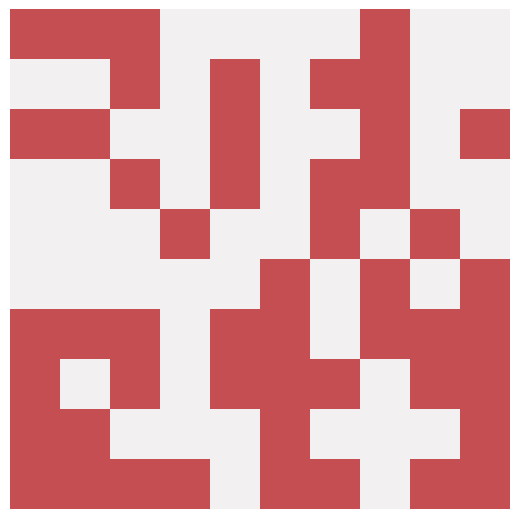

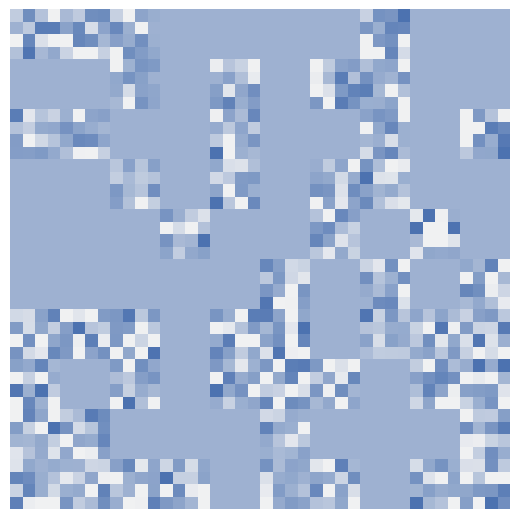

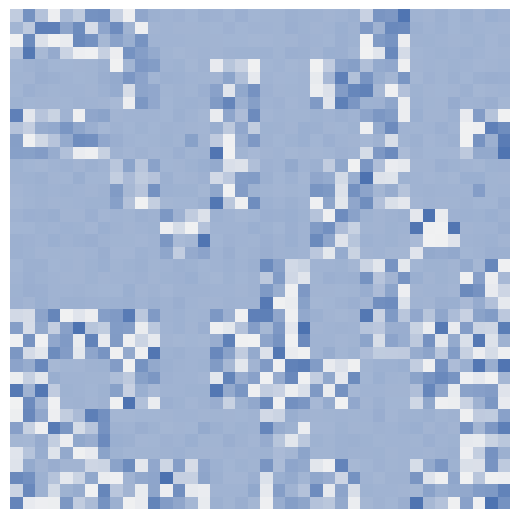


Done. Counterfactual plots saved to: exp1


In [ ]:
# ============================================================
# Cell 2b: Counterfactual visualization for Exp 1a
# ============================================================

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# Parameters
# ============================================================

EXP_DIR = "exp1"
ROW = 100
COL = 16

row_side = int(math.sqrt(ROW))
col_side = int(math.sqrt(COL))
grid_side = row_side * col_side

if row_side * row_side != ROW:
    raise ValueError(f"ROW={ROW} must be a perfect square.")

if col_side * col_side != COL:
    raise ValueError(f"COL={COL} must be a perfect square.")


# ============================================================
# Colors and style
# ============================================================

colors = sns.color_palette("deep")

red_cmap  = sns.light_palette(colors[3], as_cmap=True)  # Red, Treatment
blue_cmap = sns.light_palette(colors[0], as_cmap=True)  # Blue, Outcome


# ============================================================
# Grid conversion
# ============================================================

def matrix_to_grid(M):
    """
    Convert ROW x COL matrix into spatial grid.

    ROW regions form sqrt(ROW) x sqrt(ROW).
    COL subregions form sqrt(COL) x sqrt(COL) inside each region.
    """
    M = np.asarray(M)

    if M.shape != (ROW, COL):
        raise ValueError(f"Expected matrix shape {(ROW, COL)}, got {M.shape}.")

    grid = np.zeros((grid_side, grid_side), dtype=float)

    for r in range(ROW):
        region_row = r // row_side
        region_col = r % row_side

        start_i = region_row * col_side
        start_j = region_col * col_side

        block = M[r].reshape(col_side, col_side)

        grid[
            start_i:start_i + col_side,
            start_j:start_j + col_side,
        ] = block

    return grid


# ============================================================
# Plot helper
# ============================================================

def save_heatmap(
    data,
    cmap,
    filename,
    figsize=(5, 5),
    vmin=None,
    vmax=None,
    linewidths=0,
    cbar=False,
):
    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        data,
        ax=ax,
        cmap=cmap,
        square=True,
        linewidths=linewidths,
        cbar=cbar,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

    plt.tight_layout(pad=0)

    fig.savefig(os.path.join(EXP_DIR, f"{filename}.jpg"), dpi=300, bbox_inches="tight", pad_inches=0)
    fig.savefig(os.path.join(EXP_DIR, f"{filename}.pdf"), bbox_inches="tight", pad_inches=0)

    plt.show()
    plt.close(fig)


# ============================================================
# Counterfactual construction
# ============================================================

# Invert treatment matrix
T_cf = 1.0 - T

# Ground-truth counterfactual outcome
Y_cf_true = true_f_numpy(T_cf, C)

# Estimated counterfactual outcome using learned neural approximation from exp1a
Y_cf_est = predict_matrix(model_1a, T_cf, C)


# ============================================================
# Save counterfactual matrices
# ============================================================

pd.DataFrame(T_cf).to_csv(os.path.join(EXP_DIR, "T_cf.csv"), index=False, header=False)
pd.DataFrame(Y_cf_true).to_csv(os.path.join(EXP_DIR, "Y_cf_true.csv"), index=False, header=False)
pd.DataFrame(Y_cf_est).to_csv(os.path.join(EXP_DIR, "Y_cf_est_1a.csv"), index=False, header=False)


# ============================================================
# Counterfactual heatmaps
# ============================================================

# Inverted treatment matrix
save_heatmap(
    matrix_to_grid(T_cf),
    red_cmap,
    "T_cf_grid",
    figsize=(5, 5),
    vmin=0,
    vmax=1,
    linewidths=0,
    cbar=False,
)

# Use shared color scale for true and estimated counterfactual outcomes
y_cf_min = min(Y_cf_true.min(), Y_cf_est.min())
y_cf_max = max(Y_cf_true.max(), Y_cf_est.max())

save_heatmap(
    matrix_to_grid(Y_cf_true),
    blue_cmap,
    "Y_cf_true_grid",
    figsize=(5, 5),
    vmin=y_cf_min,
    vmax=y_cf_max,
    linewidths=0,
    cbar=False,
)

save_heatmap(
    matrix_to_grid(Y_cf_est),
    blue_cmap,
    "Y_cf_est_1a_grid",
    figsize=(5, 5),
    vmin=y_cf_min,
    vmax=y_cf_max,
    linewidths=0,
    cbar=False,
)


print("\nDone. Counterfactual plots saved to:", EXP_DIR)

### Ablation

In [ ]:
# ============================================================
# Cell 1: Run exp1c experiments and save CSV outputs
# ============================================================

import os
import math
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt


# ============================================================
# Hyperparameters and parameters
# ============================================================

ROW = 100
COL = 16

EXP_DIR = "exp1"
EXP1C_DIR = os.path.join(EXP_DIR, "exp1c")

SEEDS = list(range(42, 47))  # 10 seeds: 42, ..., 51

REG_STD_VALUES = np.round(np.arange(0.1, 1.01, 0.1), 1)
SUBREG_STD_VALUES = np.round(np.arange(0.1, 1.01, 0.1), 1)

NOISE_STD = 0.1              # Gaussian noise added to Y
FINAL_C_NOISE_STD = 1e-3     # Tiny final noise added to C after exact scaling

N_EPOCHS = 2000
LR = 1e-3
WEIGHT_DECAY = 1e-3
HIDDEN_DIM = 32
DROPOUT = 0.05

PRINT_INTERVAL = 1000        # Less verbose than exp1a because exp1c runs many experiments

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# ============================================================
# Reproducibility
# ============================================================

def set_all_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass


# ============================================================
# Validation and folders
# ============================================================

def is_perfect_square(x):
    r = int(math.sqrt(x))
    return r * r == x


if not is_perfect_square(ROW):
    raise ValueError(f"ROW={ROW} must be a perfect square.")

if not is_perfect_square(COL):
    raise ValueError(f"COL={COL} must be a perfect square.")

os.makedirs(EXP1C_DIR, exist_ok=True)


# ============================================================
# Filename helper
# ============================================================

def fmt_float(x):
    return f"{x:.1f}".replace(".", "p")


def make_suffix(seed, reg_std, subreg_std):
    return f"seed{seed}_reg{fmt_float(reg_std)}_sub{fmt_float(subreg_std)}"


# ============================================================
# Ground-truth function f(t, c)
# ============================================================

def true_f_numpy(t, c):
    """
    Ground-truth function.

    If t == 0:
        f = 1

    If t == 1:
        f is given by piecewise linear interpolation over c
        using anchor points:
            (-100, 2), (-2, 2), (0, 1), (1, 0), (100, 0)
    """
    t = np.asarray(t)
    c = np.asarray(c)

    anchor_x = np.array([-100, -2, 0, 1, 100], dtype=float)
    anchor_y = np.array([2, 2, 1, 0, 0], dtype=float)

    y_t1 = np.interp(c, anchor_x, anchor_y)
    y = np.where(t == 0, 1.0, y_t1)

    return y.astype(float)


# ============================================================
# Data generation
# ============================================================

def create_treatment_matrix(row, col):
    """
    Create treatment matrix T.

    Exactly half of the rows are all ones and half are all zeros.
    """
    if row % 2 != 0:
        raise ValueError("ROW must be even to assign exactly half treated rows.")

    row_flags = np.array([1] * (row // 2) + [0] * (row // 2))
    np.random.shuffle(row_flags)

    T = np.repeat(row_flags[:, None], col, axis=1)

    return T.astype(float)


def zscore_to_std(x, target_std, axis=None, keepdims=False, eps=1e-12):
    """
    Z-score x and multiply by target_std.
    Uses population std, matching np.std default ddof=0.
    """
    x = np.asarray(x, dtype=float)
    mean = x.mean(axis=axis, keepdims=keepdims)
    std = x.std(axis=axis, keepdims=keepdims)

    std_safe = np.where(std < eps, 1.0, std)

    return (x - mean) / std_safe * target_std


def create_context_matrix_exp1c(row, col, reg_std, subreg_std, final_noise_std=1e-3):
    """
    Create context matrix C for exp1c.

    Target properties before final tiny noise:

    1. The row means have std exactly reg_std.
    2. Within each row, the std over columns is exactly subreg_std.
    3. The row means are preserved while scaling within-row deviations.
    4. A tiny final noise is added at the end.
    """

    # --------------------------------------------------------
    # Step 1: Sample one mean per row, z-score, scale to reg_std
    # --------------------------------------------------------
    row_means = np.random.normal(loc=0.0, scale=1.0, size=(row, 1))
    row_means = zscore_to_std(row_means, target_std=reg_std, axis=0, keepdims=True)

    # --------------------------------------------------------
    # Step 2: Sample within-row deviations
    # --------------------------------------------------------
    deviations = np.random.normal(loc=0.0, scale=1.0, size=(row, col))

    # Remove row means so deviations have row mean zero
    deviations = deviations - deviations.mean(axis=1, keepdims=True)

    # Scale each row to have exact std subreg_std over columns
    row_stds = deviations.std(axis=1, keepdims=True)

    if np.any(row_stds < 1e-12):
        raise RuntimeError("A sampled row had near-zero std. Re-run with a different seed.")

    deviations = deviations / row_stds * subreg_std

    # --------------------------------------------------------
    # Step 3: Add deviations to row means.
    # This preserves row means exactly before final noise.
    # --------------------------------------------------------
    C = row_means + deviations

    # --------------------------------------------------------
    # Step 4: Add final tiny noise
    # --------------------------------------------------------
    if final_noise_std > 0:
        C = C + np.random.normal(loc=0.0, scale=final_noise_std, size=(row, col))

    return C.astype(float)


def generate_data(seed, reg_std, subreg_std):
    """
    Generate one full exp1c dataset.
    """
    set_all_seeds(seed)

    T = create_treatment_matrix(ROW, COL)
    C = create_context_matrix_exp1c(
        ROW,
        COL,
        reg_std=reg_std,
        subreg_std=subreg_std,
        final_noise_std=FINAL_C_NOISE_STD,
    )

    Y_clean = true_f_numpy(T, C)
    Y = Y_clean + np.random.normal(loc=0.0, scale=NOISE_STD, size=(ROW, COL))

    T_agg = T.mean(axis=1)
    C_agg = C.mean(axis=1)
    Y_agg = Y.mean(axis=1)

    Y_disagg = np.repeat(Y_agg[:, None], COL, axis=1)

    E_true = true_f_numpy(T, C) - true_f_numpy(np.zeros_like(T), C)

    return {
        "T": T,
        "C": C,
        "Y": Y,
        "Y_clean": Y_clean,
        "T_agg": T_agg,
        "C_agg": C_agg,
        "Y_agg": Y_agg,
        "Y_disagg": Y_disagg,
        "E_true": E_true,
    }


# ============================================================
# Model
# ============================================================

class SmallMLP(nn.Module):
    """
    Simple neural network approximating f(t, c).
    """
    def __init__(self, hidden_dim=64, dropout=0.05):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def make_features(T, C):
    """
    Convert T and C matrices into feature tensor with shape ROW x COL x 2.
    """
    X = np.stack([T, C], axis=-1)
    return X.astype(np.float32)


def predict_matrix(model, T_np, C_np):
    """
    Predict element-wise outcome matrix using model f_rec(t, c).
    """
    model.eval()

    X_np = make_features(T_np, C_np)
    X_t = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)

    with torch.no_grad():
        pred = model(X_t.reshape(-1, 2)).reshape(T_np.shape)

    return pred.detach().cpu().numpy()


def compute_locate_matrix(model, T_np, C_np):
    """
    Compute LOCATE:
        E_ij = f_rec(t_ij, c_ij) - f_rec(0, c_ij)
    """
    Y_treated_or_observed = predict_matrix(model, T_np, C_np)
    Y_control = predict_matrix(model, np.zeros_like(T_np), C_np)

    return Y_treated_or_observed - Y_control


def compute_locate_mae_torch(model, T_t, C_t, E_true_t):
    """
    Compute current LOCATE MAE during training.
    """
    X_obs = torch.stack([T_t, C_t], dim=-1)
    X_zero = torch.stack([torch.zeros_like(T_t), C_t], dim=-1)

    pred_obs = model(X_obs.reshape(-1, 2)).reshape(T_t.shape)
    pred_zero = model(X_zero.reshape(-1, 2)).reshape(T_t.shape)

    E_pred = pred_obs - pred_zero
    locate_mae = torch.mean(torch.abs(E_pred - E_true_t))

    return locate_mae


# ============================================================
# Experiment 1c: exp1a repeated over reg_std/subreg_std grid
# ============================================================

def train_exp1c_single(T, C, Y, Y_agg, E_true, seed, reg_std, subreg_std):
    """
    Same training objective as exp1a:
    train f_rec using only row-aggregated outcome loss.
    """
    set_all_seeds(seed)

    model = SmallMLP(hidden_dim=HIDDEN_DIM, dropout=DROPOUT).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    X_np = make_features(T, C)

    X_t = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)
    T_t = torch.tensor(T, dtype=torch.float32, device=DEVICE)
    C_t = torch.tensor(C, dtype=torch.float32, device=DEVICE)
    Y_t = torch.tensor(Y, dtype=torch.float32, device=DEVICE)
    Y_agg_t = torch.tensor(Y_agg, dtype=torch.float32, device=DEVICE)
    E_true_t = torch.tensor(E_true, dtype=torch.float32, device=DEVICE)

    history = []

    for epoch in range(1, N_EPOCHS + 1):
        model.train()

        pred = model(X_t.reshape(-1, 2)).reshape(ROW, COL)
        pred_agg = pred.mean(dim=1)

        loss = torch.mean((pred_agg - Y_agg_t) ** 2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            prediction_error = torch.mean((pred - Y_t) ** 2)
            locate_mae = compute_locate_mae_torch(model, T_t, C_t, E_true_t)

        history.append({
            "seed": seed,
            "reg_std": reg_std,
            "subreg_std": subreg_std,
            "epoch": epoch,
            "training_loss": loss.item(),
            "prediction_error": prediction_error.item(),
            "locate_mae": locate_mae.item(),
        })

        if epoch % PRINT_INTERVAL == 0 or epoch == 1:
            print(
                f"[Exp 1c] seed={seed} | reg_std={reg_std:.1f} | subreg_std={subreg_std:.1f} | "
                f"epoch={epoch:04d} | loss={loss.item():.6f} | "
                f"prediction_error={prediction_error.item():.6f} | "
                f"locate_mae={locate_mae.item():.6f}"
            )

    return model, pd.DataFrame(history)


# ============================================================
# Main loop
# ============================================================

summary_rows = []

total_runs = len(SEEDS) * len(REG_STD_VALUES) * len(SUBREG_STD_VALUES)
run_idx = 0

for seed in SEEDS:
    for reg_std in REG_STD_VALUES:
        for subreg_std in SUBREG_STD_VALUES:
            run_idx += 1

            print(
                f"\n=== Running {run_idx}/{total_runs}: "
                f"seed={seed}, reg_std={reg_std:.1f}, subreg_std={subreg_std:.1f} ==="
            )

            suffix = make_suffix(seed, reg_std, subreg_std)

            data = generate_data(seed, reg_std, subreg_std)

            T = data["T"]
            C = data["C"]
            Y = data["Y"]
            Y_clean = data["Y_clean"]
            T_agg = data["T_agg"]
            C_agg = data["C_agg"]
            Y_agg = data["Y_agg"]
            Y_disagg = data["Y_disagg"]
            E_true = data["E_true"]

            # ------------------------------------------------
            # Save generated data, same style as exp1a
            # ------------------------------------------------
            pd.DataFrame(T).to_csv(os.path.join(EXP1C_DIR, f"T_{suffix}.csv"), index=False, header=False)
            pd.DataFrame(C).to_csv(os.path.join(EXP1C_DIR, f"C_{suffix}.csv"), index=False, header=False)
            pd.DataFrame(Y).to_csv(os.path.join(EXP1C_DIR, f"Y_{suffix}.csv"), index=False, header=False)
            pd.DataFrame(Y_clean).to_csv(os.path.join(EXP1C_DIR, f"Y_clean_{suffix}.csv"), index=False, header=False)

            pd.DataFrame(T_agg).to_csv(os.path.join(EXP1C_DIR, f"T_agg_{suffix}.csv"), index=False, header=False)
            pd.DataFrame(C_agg).to_csv(os.path.join(EXP1C_DIR, f"C_agg_{suffix}.csv"), index=False, header=False)
            pd.DataFrame(Y_agg).to_csv(os.path.join(EXP1C_DIR, f"Y_agg_{suffix}.csv"), index=False, header=False)

            pd.DataFrame(Y_disagg).to_csv(os.path.join(EXP1C_DIR, f"Y_disagg_{suffix}.csv"), index=False, header=False)
            pd.DataFrame(E_true).to_csv(os.path.join(EXP1C_DIR, f"LOCATE_true_{suffix}.csv"), index=False, header=False)

            # ------------------------------------------------
            # Train exp1a-style aggregated-loss model
            # ------------------------------------------------
            model_1c, hist_1c = train_exp1c_single(
                T=T,
                C=C,
                Y=Y,
                Y_agg=Y_agg,
                E_true=E_true,
                seed=seed,
                reg_std=reg_std,
                subreg_std=subreg_std,
            )

            Y_rec_1c = predict_matrix(model_1c, T, C)
            E_1c = compute_locate_matrix(model_1c, T, C)

            hist_1c.to_csv(os.path.join(EXP1C_DIR, f"history_1c_{suffix}.csv"), index=False)
            pd.DataFrame(Y_rec_1c).to_csv(os.path.join(EXP1C_DIR, f"Y_rec_1c_{suffix}.csv"), index=False, header=False)
            pd.DataFrame(E_1c).to_csv(os.path.join(EXP1C_DIR, f"LOCATE_1c_{suffix}.csv"), index=False, header=False)

            final_row = hist_1c.iloc[-1].to_dict()

            # Diagnostics after final noise
            final_row.update({
                "C_row_mean_std_after_noise": C.mean(axis=1).std(),
                "C_within_row_std_mean_after_noise": C.std(axis=1).mean(),
                "C_within_row_std_min_after_noise": C.std(axis=1).min(),
                "C_within_row_std_max_after_noise": C.std(axis=1).max(),
            })

            summary_rows.append(final_row)


# ============================================================
# Save summary and metadata
# ============================================================

summary = pd.DataFrame(summary_rows)
summary.to_csv(os.path.join(EXP1C_DIR, "summary_1c.csv"), index=False)

metadata = pd.DataFrame({
    "parameter": [
        "ROW",
        "COL",
        "SEEDS",
        "REG_STD_VALUES",
        "SUBREG_STD_VALUES",
        "NOISE_STD",
        "FINAL_C_NOISE_STD",
        "N_EPOCHS",
        "LR",
        "WEIGHT_DECAY",
        "HIDDEN_DIM",
        "DROPOUT",
        "PRINT_INTERVAL",
        "DEVICE",
    ],
    "value": [
        ROW,
        COL,
        str(SEEDS),
        str(list(REG_STD_VALUES)),
        str(list(SUBREG_STD_VALUES)),
        NOISE_STD,
        FINAL_C_NOISE_STD,
        N_EPOCHS,
        LR,
        WEIGHT_DECAY,
        HIDDEN_DIM,
        DROPOUT,
        PRINT_INTERVAL,
        DEVICE,
    ],
})

metadata.to_csv(os.path.join(EXP1C_DIR, "metadata_1c.csv"), index=False)

print("\nDone. Exp1c CSV outputs written to:", EXP1C_DIR)


=== Running 1/500: seed=42, reg_std=0.1, subreg_std=0.1 ===
[Exp 1c] seed=42 | reg_std=0.1 | subreg_std=0.1 | epoch=0001 | loss=1.021523 | prediction_error=1.034302 | locate_mae=0.062078
[Exp 1c] seed=42 | reg_std=0.1 | subreg_std=0.1 | epoch=1000 | loss=0.000828 | prediction_error=0.015759 | locate_mae=0.087559
[Exp 1c] seed=42 | reg_std=0.1 | subreg_std=0.1 | epoch=2000 | loss=0.000933 | prediction_error=0.014904 | locate_mae=0.079195

=== Running 2/500: seed=42, reg_std=0.1, subreg_std=0.2 ===
[Exp 1c] seed=42 | reg_std=0.1 | subreg_std=0.2 | epoch=0001 | loss=1.003153 | prediction_error=1.025264 | locate_mae=0.086194
[Exp 1c] seed=42 | reg_std=0.1 | subreg_std=0.2 | epoch=1000 | loss=0.000914 | prediction_error=0.018785 | locate_mae=0.095069
[Exp 1c] seed=42 | reg_std=0.1 | subreg_std=0.2 | epoch=2000 | loss=0.000929 | prediction_error=0.017174 | locate_mae=0.083677

=== Running 3/500: seed=42, reg_std=0.1, subreg_std=0.3 ===
[Exp 1c] seed=42 | reg_std=0.1 | subreg_std=0.3 | epoch

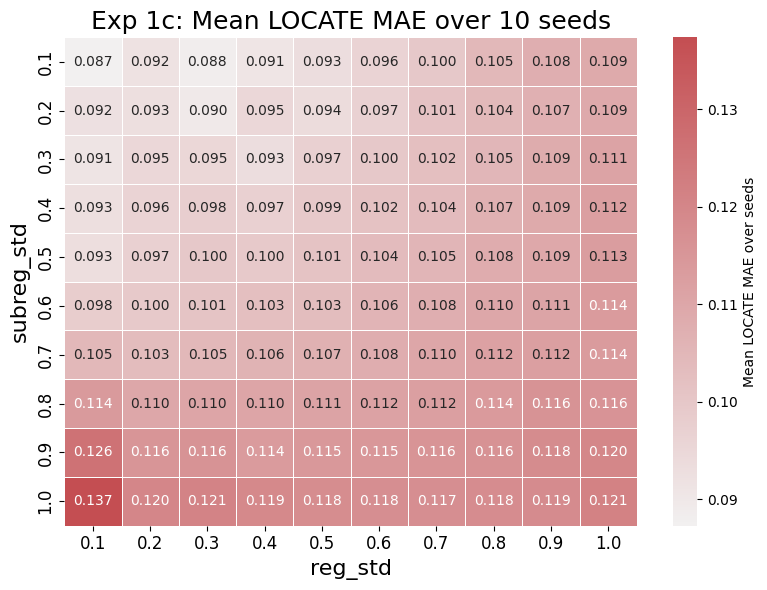


Done. Exp1c heatmap saved to: exp1/exp1c


In [ ]:
# ============================================================
# Cell 2: Read exp1c CSV outputs and create aggregate heatmap
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# Parameters
# ============================================================

EXP_DIR = "exp1"
EXP1C_DIR = os.path.join(EXP_DIR, "exp1c")

REG_STD_VALUES = np.round(np.arange(0.1, 1.01, 0.1), 1)
SUBREG_STD_VALUES = np.round(np.arange(0.1, 1.01, 0.1), 1)


# ============================================================
# Colors and style
# ============================================================

colors = sns.color_palette("deep")

red_color = colors[3]
red_cmap = sns.light_palette(red_color, as_cmap=True)


# ============================================================
# Load summary
# ============================================================

summary = pd.read_csv(os.path.join(EXP1C_DIR, "summary_1c.csv"))


# ============================================================
# Aggregate final LOCATE MAE over seeds
# ============================================================

heatmap_df = (
    summary
    .groupby(["subreg_std", "reg_std"], as_index=False)["locate_mae"]
    .mean()
    .pivot(index="subreg_std", columns="reg_std", values="locate_mae")
)

# Ensure fixed axis order
heatmap_df = heatmap_df.loc[SUBREG_STD_VALUES, REG_STD_VALUES]


# ============================================================
# Save numeric aggregate table
# ============================================================

heatmap_df.to_csv(os.path.join(EXP1C_DIR, "locate_mae_mean_heatmap_values_1c.csv"))


# ============================================================
# Plot heatmap
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    heatmap_df,
    ax=ax,
    cmap=red_cmap,
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    cbar_kws={"label": "Mean LOCATE MAE over seeds"},
)

ax.set_xlabel("reg_std", fontsize=16)
ax.set_ylabel("subreg_std", fontsize=16)
ax.set_title("Exp 1c: Mean LOCATE MAE over 10 seeds", fontsize=18)

ax.tick_params(axis="both", labelsize=12)

plt.tight_layout()

fig.savefig(os.path.join(EXP1C_DIR, "locate_mae_mean_heatmap_1c.jpg"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(EXP1C_DIR, "locate_mae_mean_heatmap_1c.pdf"), bbox_inches="tight")

plt.show()
plt.close(fig)

print("\nDone. Exp1c heatmap saved to:", EXP1C_DIR)

### With Multiple Runs

In [ ]:
# ============================================================
# Cell 1: Run experiments and save CSV outputs
# ============================================================

import os
import math
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt


# ============================================================
# Hyperparameters and parameters
# ============================================================

SEED = 42                 # Global random seed for reproducibility
N_RUNS = 20                # Number of runs
SEEDS = range(SEED, SEED + N_RUNS)

ROW = 100                 # Number of regions
COL = 16                  # Number of subregions per region
EXP_DIR = "exp1seeds"     # Output folder for Experiment 1

N_SWAPS = 100             # Number of random pair swaps in context matrix C
NOISE_STD = 0.1           # Gaussian noise added to Y

N_EPOCHS = 4000           # Number of training epochs
LR = 1e-3                 # Learning rate
WEIGHT_DECAY = 1e-3       # AdamW weight decay for regularization
HIDDEN_DIM = 32           # Hidden layer width
DROPOUT = 0.05            # Dropout probability
PRINT_INTERVAL = 10       # Print loss every n epochs

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# ============================================================
# Reproducibility
# ============================================================

def set_all_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass


# ============================================================
# Validation
# ============================================================

def is_perfect_square(x):
    r = int(math.sqrt(x))
    return r * r == x


if not is_perfect_square(ROW):
    raise ValueError(f"ROW={ROW} must be a perfect square.")

if not is_perfect_square(COL):
    raise ValueError(f"COL={COL} must be a perfect square.")


os.makedirs(EXP_DIR, exist_ok=True)


# ============================================================
# Ground-truth function f(t, c)
# ============================================================

def true_f_numpy(t, c):
    """
    Ground-truth function.

    If t == 0:
        f = 1

    If t == 1:
        f is given by piecewise linear interpolation over c
        using anchor points:
            (-100, 2), (-2, 2), (0, 1), (1, 0), (100, 0)
    """
    t = np.asarray(t)
    c = np.asarray(c)

    anchor_x = np.array([-100, -2, 0, 1, 100], dtype=float)
    anchor_y = np.array([2, 2, 1, 0, 0], dtype=float)

    y_t1 = np.interp(c, anchor_x, anchor_y)
    y = np.where(t == 0, 1.0, y_t1)

    return y.astype(float)


# ============================================================
# Data generation
# ============================================================

def create_treatment_matrix(row, col):
    """
    Create treatment matrix T.

    Exactly half of the rows are all ones and half are all zeros.
    """
    if row % 2 != 0:
        raise ValueError("ROW must be even to assign exactly half treated rows.")

    row_flags = np.array([1] * (row // 2) + [0] * (row // 2))
    np.random.shuffle(row_flags)

    T = np.repeat(row_flags[:, None], col, axis=1)

    return T.astype(float)


def create_context_matrix(row, col, n_swaps):
    """
    Create context matrix C.

    1. Draw all entries from a normal distribution.
    2. Subtract the row mean so each row sums to zero.
    3. Randomly swap n_swaps pairs of entries.
    """
    C = np.random.normal(loc=0.0, scale=1.0, size=(row, col))
    C = C - C.mean(axis=1, keepdims=True)

    for _ in range(n_swaps):
        r1 = np.random.randint(0, row)
        c1 = np.random.randint(0, col)

        r2 = np.random.randint(0, row)
        c2 = np.random.randint(0, col)

        C[r1, c1], C[r2, c2] = C[r2, c2], C[r1, c1]

    return C.astype(float)


# ============================================================
# Model
# ============================================================

class SmallMLP(nn.Module):
    """
    Simple neural network approximating f(t, c).
    """
    def __init__(self, hidden_dim=64, dropout=0.05):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def make_features(T, C):
    """
    Convert T and C matrices into feature tensor with shape ROW x COL x 2.
    """
    X = np.stack([T, C], axis=-1)
    return X.astype(np.float32)


def predict_matrix(model, T_np, C_np):
    """
    Predict element-wise outcome matrix using model f_rec(t, c).
    """
    model.eval()

    X_np = make_features(T_np, C_np)
    X_t = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)

    with torch.no_grad():
        pred = model(X_t.reshape(-1, 2)).reshape(T_np.shape)

    return pred.detach().cpu().numpy()


def compute_locate_matrix(model, T_np, C_np):
    """
    Compute LOCATE:
        E_ij = f_rec(t_ij, c_ij) - f_rec(0, c_ij)
    """
    Y_treated_or_observed = predict_matrix(model, T_np, C_np)
    Y_control = predict_matrix(model, np.zeros_like(T_np), C_np)

    return Y_treated_or_observed - Y_control


def compute_locate_mae_torch(model, T_t, C_t, E_true_t):
    """
    Compute current LOCATE MAE during training.
    """
    X_obs = torch.stack([T_t, C_t], dim=-1)
    X_zero = torch.stack([torch.zeros_like(T_t), C_t], dim=-1)

    pred_obs = model(X_obs.reshape(-1, 2)).reshape(T_t.shape)
    pred_zero = model(X_zero.reshape(-1, 2)).reshape(T_t.shape)

    E_pred = pred_obs - pred_zero
    locate_mae = torch.mean(torch.abs(E_pred - E_true_t))

    return locate_mae


# ============================================================
# Experiment 1a: aggregated loss signal
# ============================================================

def train_exp1a(T, C, Y, Y_agg, E_true):
    """
    Train f_rec using only row-aggregated outcome loss.
    """
    set_all_seeds(SEED)

    model = SmallMLP(hidden_dim=HIDDEN_DIM, dropout=DROPOUT).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    X_np = make_features(T, C)

    X_t = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)
    T_t = torch.tensor(T, dtype=torch.float32, device=DEVICE)
    C_t = torch.tensor(C, dtype=torch.float32, device=DEVICE)
    Y_t = torch.tensor(Y, dtype=torch.float32, device=DEVICE)
    Y_agg_t = torch.tensor(Y_agg, dtype=torch.float32, device=DEVICE)
    E_true_t = torch.tensor(E_true, dtype=torch.float32, device=DEVICE)

    history = []

    for epoch in range(1, N_EPOCHS + 1):
        model.train()

        pred = model(X_t.reshape(-1, 2)).reshape(ROW, COL)
        pred_agg = pred.mean(dim=1)

        loss = torch.mean((pred_agg - Y_agg_t) ** 2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            prediction_error = torch.mean((pred - Y_t) ** 2)
            locate_mae = compute_locate_mae_torch(model, T_t, C_t, E_true_t)

        history.append({
            "epoch": epoch,
            "training_loss": loss.item(),
            "prediction_error": prediction_error.item(),
            "locate_mae": locate_mae.item(),
        })

        if epoch % PRINT_INTERVAL == 0 or epoch == 1:
            print(
                f"[Seed {SEED}] [Exp 1a] Epoch {epoch:04d} | "
                f"loss={loss.item():.6f} | "
                f"prediction_error={prediction_error.item():.6f} | "
                f"locate_mae={locate_mae.item():.6f}"
            )

    return model, pd.DataFrame(history)


# ============================================================
# Experiment 1b: uniform disaggregation baseline
# ============================================================

def train_exp1b(T, C, Y, Y_disagg, E_true):
    """
    Train f_rec2 on uniformly disaggregated outcomes.

    Here the loss is available for every element, but the target is naive.
    """
    set_all_seeds(SEED)

    model = SmallMLP(hidden_dim=HIDDEN_DIM, dropout=DROPOUT).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    X_np = make_features(T, C)

    X_t = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)
    T_t = torch.tensor(T, dtype=torch.float32, device=DEVICE)
    C_t = torch.tensor(C, dtype=torch.float32, device=DEVICE)
    Y_t = torch.tensor(Y, dtype=torch.float32, device=DEVICE)
    Y_disagg_t = torch.tensor(Y_disagg, dtype=torch.float32, device=DEVICE)
    E_true_t = torch.tensor(E_true, dtype=torch.float32, device=DEVICE)

    history = []

    for epoch in range(1, N_EPOCHS + 1):
        model.train()

        pred = model(X_t.reshape(-1, 2)).reshape(ROW, COL)

        loss = torch.mean((pred - Y_disagg_t) ** 2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            prediction_error = torch.mean((pred - Y_t) ** 2)
            locate_mae = compute_locate_mae_torch(model, T_t, C_t, E_true_t)

        history.append({
            "epoch": epoch,
            "training_loss": loss.item(),
            "prediction_error": prediction_error.item(),
            "locate_mae": locate_mae.item(),
        })

        if epoch % PRINT_INTERVAL == 0 or epoch == 1:
            print(
                f"[Seed {SEED}] [Exp 1b] Epoch {epoch:04d} | "
                f"loss={loss.item():.6f} | "
                f"prediction_error={prediction_error.item():.6f} | "
                f"locate_mae={locate_mae.item():.6f}"
            )

    return model, pd.DataFrame(history)


# ============================================================
# Run all seeds
# ============================================================

for SEED in SEEDS:
    set_all_seeds(SEED)

    suffix = "" if SEED == 42 else f"_seed{SEED}"

    T = create_treatment_matrix(ROW, COL)
    C = create_context_matrix(ROW, COL, N_SWAPS)

    Y_clean = true_f_numpy(T, C)
    Y = Y_clean + np.random.normal(loc=0.0, scale=NOISE_STD, size=(ROW, COL))

    T_agg = T.mean(axis=1)
    C_agg = C.mean(axis=1)
    Y_agg = Y.mean(axis=1)

    Y_disagg = np.repeat(Y_agg[:, None], COL, axis=1)

    E_true = true_f_numpy(T, C) - true_f_numpy(np.zeros_like(T), C)

    # ============================================================
    # Save generated data
    # ============================================================

    pd.DataFrame(T).to_csv(os.path.join(EXP_DIR, f"T{suffix}.csv"), index=False, header=False)
    pd.DataFrame(C).to_csv(os.path.join(EXP_DIR, f"C{suffix}.csv"), index=False, header=False)
    pd.DataFrame(Y).to_csv(os.path.join(EXP_DIR, f"Y{suffix}.csv"), index=False, header=False)
    pd.DataFrame(Y_clean).to_csv(os.path.join(EXP_DIR, f"Y_clean{suffix}.csv"), index=False, header=False)

    pd.DataFrame(T_agg).to_csv(os.path.join(EXP_DIR, f"T_agg{suffix}.csv"), index=False, header=False)
    pd.DataFrame(C_agg).to_csv(os.path.join(EXP_DIR, f"C_agg{suffix}.csv"), index=False, header=False)
    pd.DataFrame(Y_agg).to_csv(os.path.join(EXP_DIR, f"Y_agg{suffix}.csv"), index=False, header=False)

    pd.DataFrame(Y_disagg).to_csv(os.path.join(EXP_DIR, f"Y_disagg{suffix}.csv"), index=False, header=False)
    pd.DataFrame(E_true).to_csv(os.path.join(EXP_DIR, f"LOCATE_true{suffix}.csv"), index=False, header=False)

    # ============================================================
    # Run Experiment 1a
    # ============================================================

    model_1a, hist_1a = train_exp1a(T, C, Y, Y_agg, E_true)

    Y_rec_1a = predict_matrix(model_1a, T, C)
    E_1a = compute_locate_matrix(model_1a, T, C)

    hist_1a.to_csv(os.path.join(EXP_DIR, f"history_1a{suffix}.csv"), index=False)
    pd.DataFrame(Y_rec_1a).to_csv(os.path.join(EXP_DIR, f"Y_rec_1a{suffix}.csv"), index=False, header=False)
    pd.DataFrame(E_1a).to_csv(os.path.join(EXP_DIR, f"LOCATE_1a{suffix}.csv"), index=False, header=False)

    # ============================================================
    # Run Experiment 1b
    # ============================================================

    model_1b, hist_1b = train_exp1b(T, C, Y, Y_disagg, E_true)

    Y_rec_1b = predict_matrix(model_1b, T, C)
    E_1b = compute_locate_matrix(model_1b, T, C)

    hist_1b.to_csv(os.path.join(EXP_DIR, f"history_1b{suffix}.csv"), index=False)
    pd.DataFrame(Y_rec_1b).to_csv(os.path.join(EXP_DIR, f"Y_rec_1b{suffix}.csv"), index=False, header=False)
    pd.DataFrame(E_1b).to_csv(os.path.join(EXP_DIR, f"LOCATE_1b{suffix}.csv"), index=False, header=False)

    # ============================================================
    # Save experiment metadata
    # ============================================================

    metadata = pd.DataFrame({
        "parameter": [
            "SEED",
            "ROW",
            "COL",
            "N_SWAPS",
            "NOISE_STD",
            "N_EPOCHS",
            "LR",
            "WEIGHT_DECAY",
            "HIDDEN_DIM",
            "DROPOUT",
            "PRINT_INTERVAL",
        ],
        "value": [
            SEED,
            ROW,
            COL,
            N_SWAPS,
            NOISE_STD,
            N_EPOCHS,
            LR,
            WEIGHT_DECAY,
            HIDDEN_DIM,
            DROPOUT,
            PRINT_INTERVAL,
        ],
    })

    metadata.to_csv(os.path.join(EXP_DIR, f"metadata{suffix}.csv"), index=False)

print("\nDone. CSV outputs written to:", EXP_DIR)

[Seed 42] [Exp 1a] Epoch 0001 | loss=0.910336 | prediction_error=1.119039 | locate_mae=0.277868
[Seed 42] [Exp 1a] Epoch 0010 | loss=0.613064 | prediction_error=0.827778 | locate_mae=0.279406
[Seed 42] [Exp 1a] Epoch 0020 | loss=0.346482 | prediction_error=0.568275 | locate_mae=0.289630
[Seed 42] [Exp 1a] Epoch 0030 | loss=0.146115 | prediction_error=0.380957 | locate_mae=0.301796
[Seed 42] [Exp 1a] Epoch 0040 | loss=0.054735 | prediction_error=0.321376 | locate_mae=0.322156
[Seed 42] [Exp 1a] Epoch 0050 | loss=0.046636 | prediction_error=0.331999 | locate_mae=0.321667
[Seed 42] [Exp 1a] Epoch 0060 | loss=0.031276 | prediction_error=0.303912 | locate_mae=0.301936
[Seed 42] [Exp 1a] Epoch 0070 | loss=0.020772 | prediction_error=0.299767 | locate_mae=0.279151
[Seed 42] [Exp 1a] Epoch 0080 | loss=0.014992 | prediction_error=0.300338 | locate_mae=0.276277
[Seed 42] [Exp 1a] Epoch 0090 | loss=0.011747 | prediction_error=0.292769 | locate_mae=0.280894
[Seed 42] [Exp 1a] Epoch 0100 | loss=0.0

KeyboardInterrupt: 

In [ ]:
# ============================================================
# Cell 2: Read CSV outputs and create JPG/PDF plots
# ============================================================

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch


# ============================================================
# Parameters
# ============================================================

EXP_DIR = "exp1seeds"
ROW = 100
COL = 16

SEED = 42
N_RUNS = 5
SEEDS = range(SEED, SEED + N_RUNS)
BASE_SEED = SEED

SMOOTHING_WINDOW = 45  # Moving-average window for smoothing loss curves. Use 1 for no smoothing.
N_BOOTSTRAPS = 1000    # Bootstrap resamples for confidence intervals.
CI_LEVEL = 95          # Bootstrap confidence interval level.

row_side = int(math.sqrt(ROW))
col_side = int(math.sqrt(COL))
grid_side = row_side * col_side

if row_side * row_side != ROW:
    raise ValueError(f"ROW={ROW} must be a perfect square.")

if col_side * col_side != COL:
    raise ValueError(f"COL={COL} must be a perfect square.")


# ============================================================
# Colors and style
# ============================================================

colors = sns.color_palette("deep")

red_cmap    = sns.light_palette(colors[3], as_cmap=True)  # Red, Treatment
blue_cmap   = sns.light_palette(colors[0], as_cmap=True)  # Blue, Outcome
green_cmap  = sns.light_palette(colors[2], as_cmap=True)  # Green, Context
pink_cmap   = sns.light_palette(colors[4], as_cmap=True)  # Pink, Backup / LOCATE
purple_cmap = sns.light_palette(colors[4], as_cmap=True)  # Purple, Backup
orange_cmap = sns.light_palette(colors[1], as_cmap=True)  # Orange, Backup

blue_color = colors[0]
red_color = colors[3]


# ============================================================
# Load CSV files
# ============================================================

def read_matrix(name):
    return pd.read_csv(os.path.join(EXP_DIR, name), header=None).values


def read_vector(name):
    return pd.read_csv(os.path.join(EXP_DIR, name), header=None).values.squeeze()


def seed_suffix(seed):
    return "" if seed == BASE_SEED else f"_seed{seed}"


def read_history(method, seed):
    suffix = seed_suffix(seed)
    return pd.read_csv(os.path.join(EXP_DIR, f"history_{method}{suffix}.csv"))


T = read_matrix("T.csv")
C = read_matrix("C.csv")
Y = read_matrix("Y.csv")

T_agg = read_vector("T_agg.csv")
C_agg = read_vector("C_agg.csv")
Y_agg = read_vector("Y_agg.csv")

E_true = read_matrix("LOCATE_true.csv")
E_1a = read_matrix("LOCATE_1a.csv")
E_1b = read_matrix("LOCATE_1b.csv")

hist_1a = pd.read_csv(os.path.join(EXP_DIR, "history_1a.csv"))
hist_1b = pd.read_csv(os.path.join(EXP_DIR, "history_1b.csv"))

hists_1a = [read_history("1a", seed) for seed in SEEDS]
hists_1b = [read_history("1b", seed) for seed in SEEDS]


# ============================================================
# Grid conversion functions
# ============================================================

def matrix_to_grid(M):
    """
    Convert ROW x COL matrix into spatial grid.

    ROW regions form sqrt(ROW) x sqrt(ROW).
    COL subregions form sqrt(COL) x sqrt(COL) inside each region.
    """
    M = np.asarray(M)

    if M.shape != (ROW, COL):
        raise ValueError(f"Expected matrix shape {(ROW, COL)}, got {M.shape}.")

    grid = np.zeros((grid_side, grid_side), dtype=float)

    for r in range(ROW):
        region_row = r // row_side
        region_col = r % row_side

        start_i = region_row * col_side
        start_j = region_col * col_side

        block = M[r].reshape(col_side, col_side)

        grid[
            start_i:start_i + col_side,
            start_j:start_j + col_side,
        ] = block

    return grid


def vector_to_regional_grid(v):
    """
    Convert length-ROW vector into sqrt(ROW) x sqrt(ROW) grid.
    """
    v = np.asarray(v)

    if v.shape[0] != ROW:
        raise ValueError(f"Expected vector of length {ROW}, got {v.shape[0]}.")

    return v.reshape(row_side, row_side)


# ============================================================
# Plotting helpers
# ============================================================

def save_heatmap(
    data,
    cmap,
    filename,
    figsize=(5, 5),
    vmin=None,
    vmax=None,
    linewidths=0,
    cbar=False,
):
    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        data,
        ax=ax,
        cmap=cmap,
        square=True,
        linewidths=linewidths,
        cbar=cbar,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

    plt.tight_layout(pad=0)

    fig.savefig(os.path.join(EXP_DIR, f"{filename}.jpg"), dpi=300, bbox_inches="tight", pad_inches=0)
    fig.savefig(os.path.join(EXP_DIR, f"{filename}.pdf"), bbox_inches="tight", pad_inches=0)

    plt.show()
    plt.close(fig)


def smooth_curve(values, window=25):
    """
    Smooth a 1D curve using a centered moving average.
    """
    values = np.asarray(values, dtype=float)

    if window <= 1:
        return values

    return pd.Series(values).rolling(
        window=window,
        center=True,
        min_periods=1,
    ).mean().values


def histories_to_array(histories, metric):
    """
    Convert a list of histories into an n_runs x n_epochs array.
    """
    curves = []

    for history in histories:
        curves.append(smooth_curve(history[metric].values, SMOOTHING_WINDOW))

    return np.vstack(curves)


def bootstrap_mean_ci(curves, n_bootstraps=N_BOOTSTRAPS, ci_level=CI_LEVEL, seed=42):
    """
    Bootstrap confidence interval for the mean curve over runs.
    """
    curves = np.asarray(curves, dtype=float)
    n_runs = curves.shape[0]

    rng = np.random.default_rng(seed)
    boot_means = np.zeros((n_bootstraps, curves.shape[1]), dtype=float)

    for b in range(n_bootstraps):
        idx = rng.integers(0, n_runs, size=n_runs)
        boot_means[b] = curves[idx].mean(axis=0)

    alpha = (100 - ci_level) / 2

    mean = curves.mean(axis=0)
    lower = np.percentile(boot_means, alpha, axis=0)
    upper = np.percentile(boot_means, 100 - alpha, axis=0)

    return mean, lower, upper


def get_loss_summary(histories):
    epochs = histories[0]["epoch"].values

    train_curves = histories_to_array(histories, "training_loss")
    locate_curves = histories_to_array(histories, "locate_mae")

    train_mean, train_lower, train_upper = bootstrap_mean_ci(train_curves)
    locate_mean, locate_lower, locate_upper = bootstrap_mean_ci(locate_curves)

    return {
        "epochs": epochs,
        "training_loss_mean": train_mean,
        "training_loss_lower": train_lower,
        "training_loss_upper": train_upper,
        "locate_mae_mean": locate_mean,
        "locate_mae_lower": locate_lower,
        "locate_mae_upper": locate_upper,
    }


loss_summary_1a = get_loss_summary(hists_1a)
loss_summary_1b = get_loss_summary(hists_1b)


def get_shared_loss_limits(summary_1a, summary_1b, loglog=False):
    """
    Shared x/y limits for Exp 1a and Exp 1b loss plots.
    """
    epochs = summary_1a["epochs"]

    locate_values = np.concatenate([
        summary_1a["locate_mae_lower"],
        summary_1a["locate_mae_upper"],
        summary_1b["locate_mae_lower"],
        summary_1b["locate_mae_upper"],
    ])

    train_values = np.concatenate([
        summary_1a["training_loss_lower"],
        summary_1a["training_loss_upper"],
        summary_1b["training_loss_lower"],
        summary_1b["training_loss_upper"],
    ])

    if loglog:
        xlim = (epochs[0], epochs[-1])
        locate_values = locate_values[locate_values > 0]
        train_values = train_values[train_values > 0]
        locate_ylim = (locate_values.min(), locate_values.max())
        train_ylim = (train_values.min(), train_values.max())
    else:
        xlim = (epochs[0], epochs[-1])
        locate_ylim = (locate_values.min(), locate_values.max())
        train_ylim = (train_values.min(), train_values.max())

    return xlim, locate_ylim, train_ylim


SHARED_LOSS_LIMITS_LINEAR = get_shared_loss_limits(loss_summary_1a, loss_summary_1b, loglog=False)
SHARED_LOSS_LIMITS_LOGLOG = get_shared_loss_limits(loss_summary_1a, loss_summary_1b, loglog=True)


def save_loss_plot(summary, filename, loglog=False, shared_limits=None):
    """
    Plot bootstrapped LOCATE MAE on left y-axis and
    bootstrapped training loss on right y-axis.
    """
    epochs = summary["epochs"]

    training_loss = summary["training_loss_mean"]
    training_loss_lower = summary["training_loss_lower"]
    training_loss_upper = summary["training_loss_upper"]

    locate_mae = summary["locate_mae_mean"]
    locate_mae_lower = summary["locate_mae_lower"]
    locate_mae_upper = summary["locate_mae_upper"]

    fig, ax_left = plt.subplots(figsize=(8, 6))

    ax_left.set_xlabel("Epoch", fontsize=18)
    ax_left.set_ylabel("LOCATE MAE", fontsize=18, color=red_color)

    if loglog:
        ax_left.loglog(
            epochs,
            locate_mae,
            color=red_color,
            linestyle="--",
            linewidth=4,
            alpha=0.9,
        )
    else:
        ax_left.plot(
            epochs,
            locate_mae,
            color=red_color,
            linestyle="--",
            linewidth=4,
            alpha=0.9,
        )

    ax_left.fill_between(
        epochs,
        locate_mae_lower,
        locate_mae_upper,
        color=red_color,
        alpha=0.2,
        linewidth=0,
    )

    ax_left.tick_params(axis="both", which="both", length=0, labelsize=16, colors=red_color)
    ax_left.spines["top"].set_visible(False)

    ax_right = ax_left.twinx()
    ax_right.set_ylabel("Training Loss", fontsize=18, color=blue_color)

    if loglog:
        ax_right.loglog(
            epochs,
            training_loss,
            color=blue_color,
            linestyle="-",
            linewidth=3,
            alpha=0.9,
        )
    else:
        ax_right.plot(
            epochs,
            training_loss,
            color=blue_color,
            linestyle="-",
            linewidth=3,
            alpha=0.9,
        )

    ax_right.fill_between(
        epochs,
        training_loss_lower,
        training_loss_upper,
        color=blue_color,
        alpha=0.2,
        linewidth=0,
    )

    ax_right.tick_params(axis="y", which="both", length=0, labelsize=16, colors=blue_color)
    ax_right.spines["top"].set_visible(False)

    if shared_limits is not None:
        xlim, locate_ylim, train_ylim = shared_limits

        ax_left.set_xlim(xlim)
        ax_left.set_ylim(locate_ylim)
        ax_right.set_ylim(train_ylim)

    plt.tight_layout()

    fig.savefig(os.path.join(EXP_DIR, f"{filename}.jpg"), dpi=300, bbox_inches="tight")
    fig.savefig(os.path.join(EXP_DIR, f"{filename}.pdf"), bbox_inches="tight")

    plt.show()
    plt.close(fig)


def save_combined_loss_plot(summary_1a, summary_1b, filename, loglog=False, shared_limits=None):
    """
    Combined bootstrapped loss curve.

    Exp 1a is full opacity.
    Exp 1b is 20% opacity.
    """
    epochs = summary_1a["epochs"]

    fig, ax_left = plt.subplots(figsize=(8, 6))

    ax_left.set_xlabel("Epoch", fontsize=18)
    ax_left.set_ylabel("LOCATE MAE", fontsize=18, color=red_color)

    plot_fn_left = ax_left.loglog if loglog else ax_left.plot

    plot_fn_left(
        epochs,
        summary_1a["locate_mae_mean"],
        color=red_color,
        linestyle="--",
        linewidth=4,
        alpha=0.9,
    )

    ax_left.fill_between(
        epochs,
        summary_1a["locate_mae_lower"],
        summary_1a["locate_mae_upper"],
        color=red_color,
        alpha=0.2,
        linewidth=0,
    )

    plot_fn_left(
        epochs,
        summary_1b["locate_mae_mean"],
        color=red_color,
        linestyle="--",
        linewidth=4,
        alpha=0.2,
    )

    ax_left.fill_between(
        epochs,
        summary_1b["locate_mae_lower"],
        summary_1b["locate_mae_upper"],
        color=red_color,
        alpha=0.08,
        linewidth=0,
    )

    ax_left.tick_params(axis="both", which="both", length=0, labelsize=16, colors=red_color)
    ax_left.spines["top"].set_visible(False)

    ax_right = ax_left.twinx()
    ax_right.set_ylabel("Training Loss", fontsize=18, color=blue_color)

    plot_fn_right = ax_right.loglog if loglog else ax_right.plot

    plot_fn_right(
        epochs,
        summary_1a["training_loss_mean"],
        color=blue_color,
        linestyle="-",
        linewidth=3,
        alpha=0.9,
    )

    ax_right.fill_between(
        epochs,
        summary_1a["training_loss_lower"],
        summary_1a["training_loss_upper"],
        color=blue_color,
        alpha=0.2,
        linewidth=0,
    )

    plot_fn_right(
        epochs,
        summary_1b["training_loss_mean"],
        color=blue_color,
        linestyle="-",
        linewidth=3,
        alpha=0.2,
    )

    ax_right.fill_between(
        epochs,
        summary_1b["training_loss_lower"],
        summary_1b["training_loss_upper"],
        color=blue_color,
        alpha=0.08,
        linewidth=0,
    )

    ax_right.tick_params(axis="y", which="both", length=0, labelsize=16, colors=blue_color)
    ax_right.spines["top"].set_visible(False)

    if shared_limits is not None:
        xlim, locate_ylim, train_ylim = shared_limits

        ax_left.set_xlim(xlim)
        ax_left.set_ylim(locate_ylim)
        ax_right.set_ylim(train_ylim)

    plt.tight_layout()

    fig.savefig(os.path.join(EXP_DIR, f"{filename}.jpg"), dpi=300, bbox_inches="tight")
    fig.savefig(os.path.join(EXP_DIR, f"{filename}.pdf"), bbox_inches="tight")

    plt.show()
    plt.close(fig)


# ============================================================
# Input matrix heatmaps
# ============================================================

save_heatmap(
    matrix_to_grid(T),
    red_cmap,
    "T_grid",
    figsize=(5, 5),
    vmin=0,
    vmax=1,
    linewidths=0,
    cbar=False,
)

save_heatmap(
    matrix_to_grid(C),
    green_cmap,
    "C_grid",
    figsize=(5, 5),
    vmin=np.percentile(C, 1),
    vmax=np.percentile(C, 99),
    linewidths=0,
    cbar=False,
)

save_heatmap(
    matrix_to_grid(Y),
    blue_cmap,
    "Y_grid",
    figsize=(5, 5),
    vmin=np.percentile(Y, 1),
    vmax=np.percentile(Y, 99),
    linewidths=0,
    cbar=False,
)


# ============================================================
# Aggregated vector heatmaps
# ============================================================

save_heatmap(
    vector_to_regional_grid(T_agg),
    red_cmap,
    "T_agg_grid",
    figsize=(5, 5),
    vmin=0,
    vmax=1,
    linewidths=1,
    cbar=False,
)

save_heatmap(
    vector_to_regional_grid(C_agg),
    green_cmap,
    "C_agg_grid",
    figsize=(5, 5),
    vmin=np.percentile(C_agg, 1),
    vmax=np.percentile(C_agg, 99),
    linewidths=1,
    cbar=False,
)

save_heatmap(
    vector_to_regional_grid(Y_agg),
    blue_cmap,
    "Y_agg_grid",
    figsize=(5, 5),
    vmin=np.percentile(Y_agg, 1),
    vmax=np.percentile(Y_agg, 99),
    linewidths=1,
    cbar=False,
)


# ============================================================
# Loss curves
# ============================================================

save_loss_plot(
    loss_summary_1a,
    "loss_1a_linear",
    loglog=False,
    shared_limits=SHARED_LOSS_LIMITS_LINEAR,
)

save_loss_plot(
    loss_summary_1a,
    "loss_1a_loglog",
    loglog=True,
    shared_limits=SHARED_LOSS_LIMITS_LOGLOG,
)

save_loss_plot(
    loss_summary_1b,
    "loss_1b_linear",
    loglog=False,
    shared_limits=SHARED_LOSS_LIMITS_LINEAR,
)

save_loss_plot(
    loss_summary_1b,
    "loss_1b_loglog",
    loglog=True,
    shared_limits=SHARED_LOSS_LIMITS_LOGLOG,
)

save_combined_loss_plot(
    loss_summary_1a,
    loss_summary_1b,
    "loss_combined_linear",
    loglog=False,
    shared_limits=SHARED_LOSS_LIMITS_LINEAR,
)

save_combined_loss_plot(
    loss_summary_1a,
    loss_summary_1b,
    "loss_combined_loglog",
    loglog=True,
    shared_limits=SHARED_LOSS_LIMITS_LOGLOG,
)


# ============================================================
# LOCATE matrix heatmaps
# ============================================================

locate_min = min(E_true.min(), E_1a.min(), E_1b.min())
locate_max = max(E_true.max(), E_1a.max(), E_1b.max())

save_heatmap(
    matrix_to_grid(E_true),
    pink_cmap,
    "LOCATE_true_grid",
    figsize=(5, 5),
    vmin=locate_min,
    vmax=locate_max,
    linewidths=0,
    cbar=False,
)

save_heatmap(
    matrix_to_grid(E_1a),
    pink_cmap,
    "LOCATE_1a_grid",
    figsize=(5, 5),
    vmin=locate_min,
    vmax=locate_max,
    linewidths=0,
    cbar=False,
)

save_heatmap(
    matrix_to_grid(E_1b),
    pink_cmap,
    "LOCATE_1b_grid",
    figsize=(5, 5),
    vmin=locate_min,
    vmax=locate_max,
    linewidths=0,
    cbar=False,
)


print("\nDone. Plots saved to:", EXP_DIR)

### Download

In [ ]:
# ============================================================
# Zip all of exp1/ in Google Colab
# ============================================================

import os
import shutil
from google.colab import files

EXP_DIR = "exp1seeds"
ZIP_NAME = "exp1_outputs"

if not os.path.exists(EXP_DIR):
    raise FileNotFoundError(f"Could not find folder: {EXP_DIR}")

zip_path = shutil.make_archive(
    base_name=ZIP_NAME,
    format="zip",
    root_dir=".",
    base_dir=EXP_DIR,
)

print(f"Created zip file: {zip_path}")

files.download(zip_path)

Created zip file: /content/exp1_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Exp 2

In [ ]:
# =========================
# Cell 1: Run Experiment 2
# Mini-batch version
# =========================

import os
import math
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

import seaborn as sns
import matplotlib.pyplot as plt


# -------------------------
# Hyperparameters
# -------------------------
SEED = 42

# Matrix dimensions:
# Row = number of regions
# Col = number of subregions per region
Row = 900
Col = 4

# Mini-batch size:
# 10% of rows per gradient step
BATCH_FRACTION = 0.2
BATCH_SIZE = int(Row * BATCH_FRACTION)

# Ground-truth function parameters
THETA_SHIFT_TRUE = 4.2
THETA_SCALE_TRUE = 1.23

# Outcome noise:
# sigma squared = 0.01, so sigma = sqrt(0.01)
NOISE_VAR = 0.005
NOISE_STD = math.sqrt(NOISE_VAR)

# Training parameters
EPOCHS_2A = 200_000
EPOCHS_2B = 200_000
LR_2A = 1e-4
LR_2B = 1e-4
WEIGHT_DECAY = 1e-5
PRINT_INTERVAL = 1_000

# Temperature schedule for Gumbel-Softmax
TEMP_START = 2.0
TEMP_END = 0.1

# Small NN hyperparameters for Experiment 2b
HIDDEN_DIM = 16

# Output folder
OUT_DIR = "exp2"


# -------------------------
# Reproducibility
# -------------------------
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# -------------------------
# Checks
# -------------------------
def is_square(n):
    return int(math.sqrt(n)) ** 2 == n


if not is_square(Row):
    raise ValueError(f"Row must be a perfect square, got Row={Row}")

if not is_square(Col):
    raise ValueError(f"Col must be a perfect square, got Col={Col}")

if BATCH_SIZE <= 0 or BATCH_SIZE > Row:
    raise ValueError(f"BATCH_SIZE must be between 1 and Row, got {BATCH_SIZE}")

os.makedirs(OUT_DIR, exist_ok=True)


# -------------------------
# Ground-truth function f
# -------------------------
def f_true(t, c):
    """
    Ground-truth element-wise outcome function.

    f(t_ij, c_ij) = (theta_shift - c_ij) * theta_scale * t_ij
    """
    return (THETA_SHIFT_TRUE - c) * THETA_SCALE_TRUE * t


# -------------------------
# Utilities
# -------------------------
def save_matrix(name, arr):
    pd.DataFrame(arr).to_csv(os.path.join(OUT_DIR, f"{name}.csv"), index=False)


def temperature(epoch, total_epochs):
    """
    Exponential temperature decay from TEMP_START to TEMP_END.
    """
    frac = epoch / max(total_epochs - 1, 1)
    return TEMP_START * (TEMP_END / TEMP_START) ** frac


def sample_batch_indices(row_count, batch_size):
    """
    Sample a mini-batch of region rows without replacement.
    """
    return torch.randperm(row_count, device=device)[:batch_size]


def latent_to_treatment(logits_batch, T_agg_batch, temp, hard=True):
    """
    Converts latent logits T* into estimated treatment T** for a mini-batch.

    Step 1:
        Gumbel-Softmax creates a near one-hot row vector.

    Step 2:
        Multiply by Col * T_agg so that:
        - untreated rows with T_agg = 0 become all-zero rows
        - treated rows with T_agg = 1 / Col become one-hot rows
    """
    row_probs = F.gumbel_softmax(logits_batch, tau=temp, hard=hard, dim=1)
    row_mass = Col * T_agg_batch.view(-1, 1)
    return row_probs * row_mass


def hard_treatment_from_logits(logits, T_agg):
    """
    Final deterministic treatment estimate:
    argmax over columns, multiplied by Col * T_agg.
    """
    idx = logits.argmax(dim=1)
    one_hot = F.one_hot(idx, num_classes=Col).float()
    return one_hot * (Col * T_agg.view(-1, 1))


# -------------------------
# Generate data
# -------------------------
T = np.zeros((Row, Col), dtype=np.float32)

treated_rows = np.random.choice(Row, size=Row // 2, replace=False)
treated_cols = np.random.randint(0, Col, size=Row // 2)

T[treated_rows, treated_cols] = 1.0

C = np.random.normal(loc=0.0, scale=1.0, size=(Row, Col)).astype(np.float32)

Y_clean = f_true(T, C)
Y = Y_clean + np.random.normal(0.0, NOISE_STD, size=(Row, Col)).astype(np.float32)

T_agg = T.mean(axis=1).astype(np.float32)
C_agg = C.mean(axis=1).astype(np.float32)
Y_agg = Y.sum(axis=1).astype(np.float32)

LOCATE_true = f_true(T, C) - f_true(np.zeros_like(T), C)


# -------------------------
# Save generated data
# -------------------------
save_matrix("T", T)
save_matrix("C", C)
save_matrix("Y", Y)

save_matrix("T_agg", T_agg.reshape(-1, 1))
save_matrix("C_agg", C_agg.reshape(-1, 1))
save_matrix("Y_agg", Y_agg.reshape(-1, 1))

save_matrix("LOCATE_true", LOCATE_true)


# -------------------------
# Convert to torch
# -------------------------
T_torch = torch.tensor(T, device=device)
C_torch = torch.tensor(C, device=device)
Y_torch = torch.tensor(Y, device=device)

T_agg_torch = torch.tensor(T_agg, device=device)
Y_agg_torch = torch.tensor(Y_agg, device=device)

LOCATE_true_torch = torch.tensor(LOCATE_true, device=device)


# ============================================================
# Experiment 2a:
# Learn theta_shift, theta_scale, and latent treatment T*
# ============================================================
class Exp2A(nn.Module):
    def __init__(self):
        super().__init__()

        self.theta_shift = nn.Parameter(torch.tensor(3.0))
        self.theta_scale_raw = nn.Parameter(torch.tensor(0.0))

        # One latent treatment vector per region row
        self.T_logits = nn.Parameter(0.01 * torch.randn(Row, Col))

    @property
    def theta_scale(self):
        return F.softplus(self.theta_scale_raw)

    def f_rec(self, t, c):
        return (self.theta_shift - c) * self.theta_scale * t

    def forward(self, row_idx, C_input, T_agg_input, temp):
        logits_batch = self.T_logits[row_idx]
        C_batch = C_input[row_idx]
        T_agg_batch = T_agg_input[row_idx]

        T_soft = latent_to_treatment(
            logits_batch=logits_batch,
            T_agg_batch=T_agg_batch,
            temp=temp,
            hard=False,
        )

        Y_sub = self.f_rec(T_soft, C_batch)
        Y_region = Y_sub.sum(dim=1)

        return Y_region, Y_sub, T_soft


model_2a = Exp2A().to(device)
opt_2a = torch.optim.AdamW(model_2a.parameters(), lr=LR_2A, weight_decay=WEIGHT_DECAY)

logs_2a = []

for epoch in range(1, EPOCHS_2A + 1):
    temp = temperature(epoch, EPOCHS_2A)
    row_idx = sample_batch_indices(Row, BATCH_SIZE)

    opt_2a.zero_grad()

    Y_pred_agg_batch, Y_rec_batch, T_soft_batch = model_2a(
        row_idx=row_idx,
        C_input=C_torch,
        T_agg_input=T_agg_torch,
        temp=temp,
    )

    loss = F.mse_loss(Y_pred_agg_batch, Y_agg_torch[row_idx])

    loss.backward()
    opt_2a.step()

    if epoch % PRINT_INTERVAL == 0 or epoch == 1:
        with torch.no_grad():
            T_eval = hard_treatment_from_logits(model_2a.T_logits, T_agg_torch)
            Y_rec_full = model_2a.f_rec(T_eval, C_torch)

            pred_error = F.mse_loss(Y_rec_full, Y_torch).item()

            LOCATE_rec = model_2a.f_rec(T_torch, C_torch) - model_2a.f_rec(
                torch.zeros_like(T_torch), C_torch
            )
            locate_mae = torch.mean(torch.abs(LOCATE_rec - LOCATE_true_torch)).item()

            t_mae = torch.mean(torch.abs(T_eval - T_torch)).item()

            row = {
                "epoch": epoch,
                "temperature": temp,
                "batch_size": BATCH_SIZE,
                "training_loss": loss.item(),
                "prediction_error": pred_error,
                "locate_mae": locate_mae,
                "t_mae": t_mae,
                "theta_shift": model_2a.theta_shift.item(),
                "theta_scale": model_2a.theta_scale.item(),
            }
            logs_2a.append(row)

            print(
                f"[2a] epoch={epoch:6d} | "
                f"batch={BATCH_SIZE} | "
                f"loss={row['training_loss']:.6f} | "
                f"pred_mse={row['prediction_error']:.6f} | "
                f"LOCATE_MAE={row['locate_mae']:.6f} | "
                f"T_MAE={row['t_mae']:.6f}"
            )

pd.DataFrame(logs_2a).to_csv(os.path.join(OUT_DIR, "logs_2a.csv"), index=False)

with torch.no_grad():
    T_est_2a = hard_treatment_from_logits(model_2a.T_logits, T_agg_torch)

    LOCATE_2a = model_2a.f_rec(T_torch, C_torch) - model_2a.f_rec(
        torch.zeros_like(T_torch), C_torch
    )

    theta_2a = pd.DataFrame(
        {
            "theta_shift": [model_2a.theta_shift.item()],
            "theta_scale": [model_2a.theta_scale.item()],
        }
    )

save_matrix("T_est_2a", T_est_2a.detach().cpu().numpy())
save_matrix("LOCATE_2a", LOCATE_2a.detach().cpu().numpy())
theta_2a.to_csv(os.path.join(OUT_DIR, "theta_2a.csv"), index=False)

print("\nFinal inferred theta values for Experiment 2a:")
print(theta_2a)


# ============================================================
# Experiment 2b:
# Learn f_rec with a neural network and latent treatment T*
# ============================================================
class Exp2B(nn.Module):
    def __init__(self):
        super().__init__()

        # One latent treatment vector per region row
        self.T_logits = nn.Parameter(0.01 * torch.randn(Row, Col))

        self.net = nn.Sequential(
            nn.Linear(2, HIDDEN_DIM),
            nn.Tanh(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
            nn.Tanh(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
            nn.Tanh(),
            nn.Linear(HIDDEN_DIM, 1),
        )

    def f_rec(self, t, c):
        x = torch.stack([t.reshape(-1), c.reshape(-1)], dim=1)
        y = self.net(x).reshape_as(t)

        # Enforces f(0, c) approximately zero.
        # This stabilizes LOCATE-style interpretation.
        x0 = torch.stack([torch.zeros_like(t).reshape(-1), c.reshape(-1)], dim=1)
        y0 = self.net(x0).reshape_as(t)

        return y - y0

    def forward(self, row_idx, C_input, T_agg_input, temp):
        logits_batch = self.T_logits[row_idx]
        C_batch = C_input[row_idx]
        T_agg_batch = T_agg_input[row_idx]

        T_soft = latent_to_treatment(
            logits_batch=logits_batch,
            T_agg_batch=T_agg_batch,
            temp=temp,
            hard=False,
        )

        Y_sub = self.f_rec(T_soft, C_batch)
        Y_region = Y_sub.sum(dim=1)

        return Y_region, Y_sub, T_soft


model_2b = Exp2B().to(device)
opt_2b = torch.optim.AdamW(model_2b.parameters(), lr=LR_2B, weight_decay=WEIGHT_DECAY)

logs_2b = []

for epoch in range(1, EPOCHS_2B + 1):
    temp = temperature(epoch, EPOCHS_2B)
    row_idx = sample_batch_indices(Row, BATCH_SIZE)

    opt_2b.zero_grad()

    Y_pred_agg_batch, Y_rec_batch, T_soft_batch = model_2b(
        row_idx=row_idx,
        C_input=C_torch,
        T_agg_input=T_agg_torch,
        temp=temp,
    )

    loss = F.mse_loss(Y_pred_agg_batch, Y_agg_torch[row_idx])

    loss.backward()
    opt_2b.step()

    if epoch % PRINT_INTERVAL == 0 or epoch == 1:
        with torch.no_grad():
            T_eval = hard_treatment_from_logits(model_2b.T_logits, T_agg_torch)
            Y_rec_full = model_2b.f_rec(T_eval, C_torch)

            pred_error = F.mse_loss(Y_rec_full, Y_torch).item()

            LOCATE_rec = model_2b.f_rec(T_torch, C_torch) - model_2b.f_rec(
                torch.zeros_like(T_torch), C_torch
            )
            locate_mae = torch.mean(torch.abs(LOCATE_rec - LOCATE_true_torch)).item()

            t_mae = torch.mean(torch.abs(T_eval - T_torch)).item()

            row = {
                "epoch": epoch,
                "temperature": temp,
                "batch_size": BATCH_SIZE,
                "training_loss": loss.item(),
                "prediction_error": pred_error,
                "locate_mae": locate_mae,
                "t_mae": t_mae,
            }
            logs_2b.append(row)

            print(
                f"[2b] epoch={epoch:6d} | "
                f"batch={BATCH_SIZE} | "
                f"loss={row['training_loss']:.6f} | "
                f"pred_mse={row['prediction_error']:.6f} | "
                f"LOCATE_MAE={row['locate_mae']:.6f} | "
                f"T_MAE={row['t_mae']:.6f}"
            )

pd.DataFrame(logs_2b).to_csv(os.path.join(OUT_DIR, "logs_2b.csv"), index=False)

with torch.no_grad():
    T_est_2b = hard_treatment_from_logits(model_2b.T_logits, T_agg_torch)

    LOCATE_2b = model_2b.f_rec(T_torch, C_torch) - model_2b.f_rec(
        torch.zeros_like(T_torch), C_torch
    )

save_matrix("T_est_2b", T_est_2b.detach().cpu().numpy())
save_matrix("LOCATE_2b", LOCATE_2b.detach().cpu().numpy())

print("\nExperiment 2 complete. All CSV files saved in exp2/")

[2a] epoch=     1 | batch=180 | loss=4.891987 | pred_mse=3.366224 | LOCATE_MAE=0.383468 | T_MAE=0.191111
[2a] epoch=  1000 | batch=180 | loss=5.499476 | pred_mse=3.271260 | LOCATE_MAE=0.355313 | T_MAE=0.176667
[2a] epoch=  2000 | batch=180 | loss=4.573861 | pred_mse=3.378588 | LOCATE_MAE=0.325105 | T_MAE=0.177778
[2a] epoch=  3000 | batch=180 | loss=3.794488 | pred_mse=3.557149 | LOCATE_MAE=0.292871 | T_MAE=0.180556
[2a] epoch=  4000 | batch=180 | loss=2.602027 | pred_mse=3.717143 | LOCATE_MAE=0.259085 | T_MAE=0.180556
[2a] epoch=  5000 | batch=180 | loss=2.753938 | pred_mse=3.919456 | LOCATE_MAE=0.223819 | T_MAE=0.180556
[2a] epoch=  6000 | batch=180 | loss=1.951569 | pred_mse=4.088605 | LOCATE_MAE=0.187750 | T_MAE=0.178889
[2a] epoch=  7000 | batch=180 | loss=1.499765 | pred_mse=4.379842 | LOCATE_MAE=0.151410 | T_MAE=0.181667
[2a] epoch=  8000 | batch=180 | loss=1.164323 | pred_mse=4.625444 | LOCATE_MAE=0.115612 | T_MAE=0.182222
[2a] epoch=  9000 | batch=180 | loss=0.723586 | pred_ms

### Visuals

In [ ]:
# =========================
# Cell 2: Plot Experiment 2
# =========================

import os
import math
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt


# -------------------------
# Hyperparameters
# -------------------------
Row = 900
Col = 4

OUT_DIR = "exp2"

# Smoothing window for loss curves
SMOOTH_WINDOW = 7

# Figure resolution
DPI = 300


# -------------------------
# Color maps
# -------------------------
colors = sns.color_palette("deep")

red_cmap    = sns.light_palette(colors[3], as_cmap=True)  # Red, Treatment
blue_cmap   = sns.light_palette(colors[0], as_cmap=True)  # Blue, Outcome
green_cmap  = sns.light_palette(colors[2], as_cmap=True)  # Green, Context
pink_cmap   = sns.light_palette(colors[4], as_cmap=True)  # Pink, LOCATE
purple_cmap = sns.light_palette(colors[4], as_cmap=True)  # Purple, Backup
orange_cmap = sns.light_palette(colors[1], as_cmap=True)  # Orange, Backup

RED = colors[3]
BLUE = colors[0]


# -------------------------
# Checks
# -------------------------
def is_square(n):
    return int(math.sqrt(n)) ** 2 == n

if not is_square(Row):
    raise ValueError(f"Row must be a perfect square, got Row={Row}")

if not is_square(Col):
    raise ValueError(f"Col must be a perfect square, got Col={Col}")


# -------------------------
# Load data
# -------------------------
def read_matrix(name):
    return pd.read_csv(os.path.join(OUT_DIR, f"{name}.csv")).values


T = read_matrix("T")
C = read_matrix("C")
Y = read_matrix("Y")

T_agg = read_matrix("T_agg").reshape(-1)
C_agg = read_matrix("C_agg").reshape(-1)
Y_agg = read_matrix("Y_agg").reshape(-1)

LOCATE_true = read_matrix("LOCATE_true")
LOCATE_2a = read_matrix("LOCATE_2a")
LOCATE_2b = read_matrix("LOCATE_2b")

T_est_2a = read_matrix("T_est_2a")
T_est_2b = read_matrix("T_est_2b")

logs_2a = pd.read_csv(os.path.join(OUT_DIR, "logs_2a.csv"))
logs_2b = pd.read_csv(os.path.join(OUT_DIR, "logs_2b.csv"))


# -------------------------
# Matrix layout utilities
# -------------------------
def subregion_grid(M):
    """
    Converts a Row x Col matrix into a spatial grid of size:

        sqrt(Row) * sqrt(Col)  by  sqrt(Row) * sqrt(Col)

    Each matrix row is a region.
    Each column is a subregion inside that region.
    """
    sqrt_row = int(math.sqrt(Row))
    sqrt_col = int(math.sqrt(Col))

    G = np.zeros((sqrt_row * sqrt_col, sqrt_row * sqrt_col))

    for i in range(Row):
        region_r = i // sqrt_row
        region_c = i % sqrt_row

        for j in range(Col):
            sub_r = j // sqrt_col
            sub_c = j % sqrt_col

            r = region_r * sqrt_col + sub_r
            c = region_c * sqrt_col + sub_c

            G[r, c] = M[i, j]

    return G


def regional_grid(v):
    """
    Converts a length-Row vector into a sqrt(Row) x sqrt(Row) regional grid.
    """
    sqrt_row = int(math.sqrt(Row))
    return v.reshape(sqrt_row, sqrt_row)


def save_current_fig(name):
    jpg_path = os.path.join(OUT_DIR, f"{name}.jpg")
    pdf_path = os.path.join(OUT_DIR, f"{name}.pdf")

    plt.savefig(jpg_path, dpi=DPI, bbox_inches="tight")
    plt.savefig(pdf_path, dpi=DPI, bbox_inches="tight")
    plt.close()


# -------------------------
# Heatmap plotting
# -------------------------
def plot_subregional_matrix(M, title, cmap, name, vmin=None, vmax=None):
    G = subregion_grid(M)

    plt.figure(figsize=(8, 8))
    sns.heatmap(
        G,
        cmap=cmap,
        square=True,
        cbar=True,
        xticklabels=False,
        yticklabels=False,
        linewidths=0.0,
        vmin=vmin,
        vmax=vmax,
    )
    plt.title(title)
    plt.xlabel("")
    plt.ylabel("")
    save_current_fig(name)


def plot_regional_vector(v, title, cmap, name, vmin=None, vmax=None):
    G = regional_grid(v)

    plt.figure(figsize=(7, 7))
    sns.heatmap(
        G,
        cmap=cmap,
        square=True,
        cbar=True,
        xticklabels=False,
        yticklabels=False,
        linewidths=0.25,
        linecolor="white",
        vmin=vmin,
        vmax=vmax,
    )
    plt.title(title)
    plt.xlabel("")
    plt.ylabel("")
    save_current_fig(name)


# -------------------------
# Input matrix plots
# -------------------------
plot_subregional_matrix(
    T,
    title="Ground-truth Treatment T",
    cmap=red_cmap,
    name="input_T",
    vmin=0,
    vmax=1,
)

plot_subregional_matrix(
    C,
    title="Context C",
    cmap=green_cmap,
    name="input_C",
    vmin=0,
    vmax=1,
)

plot_subregional_matrix(
    Y,
    title="Outcome Y",
    cmap=blue_cmap,
    name="input_Y",
    vmin=min(0, Y.min()),
    vmax=Y.max(),
)


# -------------------------
# Aggregated vector plots
# -------------------------
plot_regional_vector(
    T_agg,
    title="Aggregated Treatment T_agg",
    cmap=red_cmap,
    name="agg_T",
    vmin=0,
    vmax=1 / Col,
)

plot_regional_vector(
    C_agg,
    title="Aggregated Context C_agg",
    cmap=green_cmap,
    name="agg_C",
    vmin=0,
    vmax=1,
)

plot_regional_vector(
    Y_agg,
    title="Aggregated Outcome Y_agg",
    cmap=blue_cmap,
    name="agg_Y",
    vmin=min(0, Y_agg.min()),
    vmax=Y_agg.max(),
)


# -------------------------
# Loss curves
# -------------------------
def smooth(x, window=SMOOTH_WINDOW):
    return pd.Series(x).rolling(window=window, min_periods=1, center=True).mean().values


def compute_shared_loss_ranges(logs_list):
    """
    Compute shared x/y axis ranges over a list of log DataFrames so that
    loss plots are visually comparable.

    Returns a dict with linear and loglog-safe limits.
    """
    epochs_all = np.concatenate([lg["epoch"].values for lg in logs_list])
    t_mae_all  = np.concatenate([smooth(lg["t_mae"].values) for lg in logs_list])
    loss_all   = np.concatenate([smooth(lg["training_loss"].values) for lg in logs_list])

    # Linear limits
    xlim_lin      = (epochs_all.min(), epochs_all.max())
    ylim_mae_lin  = (0.025, t_mae_all.max())
    ylim_loss_lin = (0.025, loss_all.max())

    # Log-log safe limits
    eps_pos = epochs_all[epochs_all > 0]

    xlim_log      = (eps_pos.min(), eps_pos.max()) if eps_pos.size else xlim_lin
    ylim_mae_log  = (0.025, t_mae_all.max())
    ylim_loss_log = (0.025, loss_all.max())

    return {
        "lin":  {"xlim": xlim_lin, "ylim_mae": ylim_mae_lin, "ylim_loss": ylim_loss_lin},
        "log":  {"xlim": xlim_log, "ylim_mae": ylim_mae_log, "ylim_loss": ylim_loss_log},
    }


SHARED = compute_shared_loss_ranges([logs_2a, logs_2b])


def plot_loss_curve(
    logs,
    title,
    name,
    loglog=False,
    xlim=None,
    ylim_mae=None,
    ylim_loss=None,
):
    epochs = logs["epoch"].values
    t_mae = smooth(logs["t_mae"].values)
    loss = smooth(logs["training_loss"].values)

    fig, ax1 = plt.subplots(figsize=(8, 5))

    ax1.plot(
        epochs,
        t_mae,
        color=RED,
        linestyle="--",
        linewidth=2,
        label="T-MAE",
    )
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("T-MAE", color=RED)
    ax1.tick_params(axis="y", labelcolor=RED)

    ax2 = ax1.twinx()
    ax2.plot(
        epochs,
        loss,
        color=BLUE,
        linestyle="-",
        linewidth=2,
        label="Training loss",
    )
    ax2.set_ylabel("Training loss", color=BLUE)
    ax2.tick_params(axis="y", labelcolor=BLUE)

    if loglog:
        ax1.set_xscale("log")
        ax1.set_yscale("log")
        ax2.set_yscale("log")

    # Apply shared axis ranges if provided
    if xlim is not None:
        ax1.set_xlim(xlim)
    if ylim_mae is not None:
        ax1.set_ylim(ylim_mae)
    if ylim_loss is not None:
        ax2.set_ylim(ylim_loss)

    plt.title(title)
    fig.tight_layout()
    save_current_fig(name)


def plot_combined_loss_curve(
    logs_a,
    logs_b,
    title,
    name,
    loglog=False,
    xlim=None,
    ylim_mae=None,
    ylim_loss=None,
    alpha_b=0.3,
):
    """
    Overlay loss/T-MAE curves of two experiments on the same figure.
    The second experiment (logs_b, i.e. NN output / 2b) is drawn with
    reduced opacity (alpha_b).
    """
    epochs_a = logs_a["epoch"].values
    t_mae_a = smooth(logs_a["t_mae"].values)
    loss_a = smooth(logs_a["training_loss"].values)

    epochs_b = logs_b["epoch"].values
    t_mae_b = smooth(logs_b["t_mae"].values)
    loss_b = smooth(logs_b["training_loss"].values)

    fig, ax1 = plt.subplots(figsize=(8, 5))

    # T-MAE: 2a full opacity, 2b at alpha_b
    ax1.plot(
        epochs_a, t_mae_a,
        color=RED, linestyle="--", linewidth=2, alpha=1.0,
        label="T-MAE (2a)",
    )
    ax1.plot(
        epochs_b, t_mae_b,
        color=RED, linestyle="--", linewidth=2, alpha=alpha_b,
        label="T-MAE (2b)",
    )
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("T-MAE", color=RED)
    ax1.tick_params(axis="y", labelcolor=RED)

    # Training loss: 2a full opacity, 2b at alpha_b
    ax2 = ax1.twinx()
    ax2.plot(
        epochs_a, loss_a,
        color=BLUE, linestyle="-", linewidth=2, alpha=1.0,
        label="Training loss (2a)",
    )
    ax2.plot(
        epochs_b, loss_b,
        color=BLUE, linestyle="-", linewidth=2, alpha=alpha_b,
        label="Training loss (2b)",
    )
    ax2.set_ylabel("Training loss", color=BLUE)
    ax2.tick_params(axis="y", labelcolor=BLUE)

    if loglog:
        ax1.set_xscale("log")
        ax1.set_yscale("log")
        ax2.set_yscale("log")

    if xlim is not None:
        ax1.set_xlim(xlim)
    if ylim_mae is not None:
        ax1.set_ylim(ylim_mae)
    if ylim_loss is not None:
        ax2.set_ylim(ylim_loss)

    # Combined legend from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=9)

    plt.title(title)
    fig.tight_layout()
    save_current_fig(name)


# Individual loss curves (now sharing axis ranges across 2a and 2b)
plot_loss_curve(
    logs_2a,
    title="Experiment 2a: T-MAE and Training Loss",
    name="loss_2a_linear",
    loglog=False,
    xlim=SHARED["lin"]["xlim"],
    ylim_mae=SHARED["lin"]["ylim_mae"],
    ylim_loss=SHARED["lin"]["ylim_loss"],
)

plot_loss_curve(
    logs_2a,
    title="Experiment 2a: T-MAE and Training Loss, Log-Log",
    name="loss_2a_loglog",
    loglog=True,
    xlim=SHARED["log"]["xlim"],
    ylim_mae=SHARED["log"]["ylim_mae"],
    ylim_loss=SHARED["log"]["ylim_loss"],
)

plot_loss_curve(
    logs_2b,
    title="Experiment 2b: T-MAE and Training Loss",
    name="loss_2b_linear",
    loglog=False,
    xlim=SHARED["lin"]["xlim"],
    ylim_mae=SHARED["lin"]["ylim_mae"],
    ylim_loss=SHARED["lin"]["ylim_loss"],
)

plot_loss_curve(
    logs_2b,
    title="Experiment 2b: T-MAE and Training Loss, Log-Log",
    name="loss_2b_loglog",
    loglog=True,
    xlim=SHARED["log"]["xlim"],
    ylim_mae=SHARED["log"]["ylim_mae"],
    ylim_loss=SHARED["log"]["ylim_loss"],
)

# Combined loss curves (2a full opacity, 2b at 30%)
plot_combined_loss_curve(
    logs_2a,
    logs_2b,
    title="Experiments 2a & 2b: T-MAE and Training Loss",
    name="loss_combined_linear",
    loglog=False,
    xlim=SHARED["lin"]["xlim"],
    ylim_mae=SHARED["lin"]["ylim_mae"],
    ylim_loss=SHARED["lin"]["ylim_loss"],
    alpha_b=0.3,
)

plot_combined_loss_curve(
    logs_2a,
    logs_2b,
    title="Experiments 2a & 2b: T-MAE and Training Loss, Log-Log",
    name="loss_combined_loglog",
    loglog=True,
    xlim=SHARED["log"]["xlim"],
    ylim_mae=SHARED["log"]["ylim_mae"],
    ylim_loss=SHARED["log"]["ylim_loss"],
    alpha_b=0.3,
)


# -------------------------
# LOCATE plots
# -------------------------
locate_vmin = min(LOCATE_true.min(), LOCATE_2a.min(), LOCATE_2b.min())
locate_vmax = max(LOCATE_true.max(), LOCATE_2a.max(), LOCATE_2b.max())

plot_subregional_matrix(
    LOCATE_true,
    title="Ground-truth LOCATE",
    cmap=pink_cmap,
    name="LOCATE_true",
    vmin=locate_vmin,
    vmax=locate_vmax,
)

plot_subregional_matrix(
    LOCATE_2a,
    title="LOCATE from Experiment 2a",
    cmap=pink_cmap,
    name="LOCATE_2a",
    vmin=locate_vmin,
    vmax=locate_vmax,
)

plot_subregional_matrix(
    LOCATE_2b,
    title="LOCATE from Experiment 2b",
    cmap=pink_cmap,
    name="LOCATE_2b",
    vmin=locate_vmin,
    vmax=locate_vmax,
)


# -------------------------
# T matrix plots
# -------------------------
plot_subregional_matrix(
    T,
    title="Ground-truth Treatment T",
    cmap=red_cmap,
    name="T_true",
    vmin=0,
    vmax=1,
)

plot_subregional_matrix(
    T_est_2a,
    title="Estimated Treatment T, Experiment 2a",
    cmap=red_cmap,
    name="T_est_2a",
    vmin=0,
    vmax=1,
)

plot_subregional_matrix(
    T_est_2b,
    title="Estimated Treatment T, Experiment 2b",
    cmap=red_cmap,
    name="T_est_2b",
    vmin=0,
    vmax=1,
)




# -------------------------
# T matrix plots with errors
# -------------------------
from matplotlib.colors import ListedColormap


def plot_t_est_with_errors(T_true, T_est, title, name):
    """
    Plot estimated treatment with error highlighting:
    - white: no predicted treatment
    - red: correctly predicted treatment location
    - pink: incorrectly predicted treatment location
    """
    M = np.zeros_like(T_est, dtype=int)

    correct_pred = (T_est > 0) & (T_true > 0)
    wrong_pred = (T_est > 0) & (T_true == 0)

    M[correct_pred] = 1
    M[wrong_pred] = 2

    G = subregion_grid(M)

    error_cmap = ListedColormap(["white", RED, colors[4]])

    plt.figure(figsize=(8, 8))
    sns.heatmap(
        G,
        cmap=error_cmap,
        square=True,
        cbar=False,
        xticklabels=False,
        yticklabels=False,
        linewidths=0.0,
        vmin=0,
        vmax=2,
    )
    plt.title(title)
    plt.xlabel("")
    plt.ylabel("")
    save_current_fig(name)


plot_t_est_with_errors(
    T,
    T_est_2a,
    title="Estimated Treatment T, Experiment 2a: Wrong Entries in Pink",
    name="T_est_2a_with_errors",
)

plot_t_est_with_errors(
    T,
    T_est_2b,
    title="Estimated Treatment T, Experiment 2b: Wrong Entries in Pink",
    name="T_est_2b_with_errors",
)





print("All plots saved as .jpg and .pdf in exp2/")







All plots saved as .jpg and .pdf in exp2/


### Download

In [ ]:
# ============================================================
# Zip all of exp2/ in Google Colab
# ============================================================

import os
import shutil
from google.colab import files

EXP_DIR = "exp2"
ZIP_NAME = "exp2_outputs"

if not os.path.exists(EXP_DIR):
    raise FileNotFoundError(f"Could not find folder: {EXP_DIR}")

zip_path = shutil.make_archive(
    base_name=ZIP_NAME,
    format="zip",
    root_dir=".",
    base_dir=EXP_DIR,
)

print(f"Created zip file: {zip_path}")

files.download(zip_path)

Created zip file: /content/exp2_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>